# **Data Loading**

In [ ]:
from google.colab import drive
import pandas as pd
import os

# Mount Google Drive
drive.mount('/content/drive')

# Specify the path to your folder in Google Drive
folder_path = '/content/drive/MyDrive/Colab Notebooks/KFUPM/Challenge2'  # Update this path

# Get a list of all CSV files in the folder
csv_files = [f for f in os.listdir(folder_path) if f.endswith('.csv')]

# Create a dictionary to store dataframes
dataframes = {}

# Loop through each CSV file
for csv_file in csv_files:
  file_path = os.path.join(folder_path, csv_file)
  try:
      # Extract file name without extension
      file_name = os.path.splitext(csv_file)[0]

      # Read CSV into a pandas DataFrame
      globals()[file_name] = pd.read_csv(file_path)
      print(f"Successfully loaded '{csv_file}' as '{file_name}'")
  except FileNotFoundError:
    print(f"File '{csv_file}' not found.")
  except pd.errors.EmptyDataError:
    print(f"File '{csv_file}' is empty.")
  except pd.errors.ParserError:
    print(f"Error parsing '{csv_file}'. Check its format.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Successfully loaded 'ownership.csv' as 'ownership'
Successfully loaded 'minerals.csv' as 'minerals'
Successfully loaded 'source_ids.csv' as 'source_ids'
Successfully loaded 'material_ids.csv' as 'material_ids'
Successfully loaded 'reserves.csv' as 'reserves'
Successfully loaded 'processing.csv' as 'processing'
Successfully loaded 'capacity.csv' as 'capacity'
Successfully loaded 'coal.csv' as 'coal'
Successfully loaded 'commodities.csv' as 'commodities'
Successfully loaded 'transport.csv' as 'transport'
Successfully loaded 'waste.csv' as 'waste'


In [ ]:
print("owership:", ownership.columns)
print("minerals:", minerals.columns)
print("commodities:", commodities.columns)
print("source_ids:", source_ids.columns)
print("material_ids:", material_ids.columns)
print("reserves:", reserves.columns)
print("processing:", processing.columns)
print("capacity:", capacity.columns)
print("coal:", coal.columns)
print("transport:", transport.columns)
print("waste:", waste.columns)

owership: Index(['id', 'facility_id', 'year', 'owners', 'operators', 'source_id',
       'comment'],
      dtype='object')
minerals: Index(['id', 'facility_id', 'year', 'type', 'material', 'value_tonnes',
       'overall_grade_ppm', 'amount_sold_tonnes', 'mine_processing',
       'reporting_period', 'source_id', 'comment'],
      dtype='object')
commodities: Index(['id', 'facility_id', 'year', 'material', 'commodity', 'value_tonnes',
       'grade_ppm', 'recovery_rate', 'yield_ppm', 'amount_sold_tonnes',
       'metal_payable_tonnes', 'mine_processing', 'reporting_period',
       'source_id', 'comment', 'id_minerals'],
      dtype='object')
source_ids: Index(['source_id', 'sources', 'source_urls'], dtype='object')
material_ids: Index(['material_id', 'material_name', 'material_category',
       'material_category_2', 'material_id_agg', 'material_name_agg',
       'materials_contained'],
      dtype='object')
reserves: Index(['id', 'facility_id', 'year', 'material', 'commodity',
       '

## **ownership**

In [ ]:
ownership.isna().sum()

,0
id,0
facility_id,0
year,0
owners,1
operators,556
source_id,0
comment,691


In [ ]:
print(f"Shape: {ownership.shape}\n")
ownership.head()

Shape (699, 7)



,id,facility_id,year,owners,operators,source_id,comment
0,1,COM00001.00,2018,Hudbay Minerals Inc (100%),NaN,det_2912,NaN
1,2,COM00005.00,2019,Rusal Plc. (100%),NaN,det_1277,NaN
2,3,COM00006.00,2019,ArcelorMittal S.A. (100%),NaN,det_1218,NaN
3,4,COM00007.00,2018,AngloGold Ashanti (100%),NaN,det_1057,NaN
4,5,COM00009.00,2017,Newmont Mining Corporation (100%),NaN,det_1595,NaN


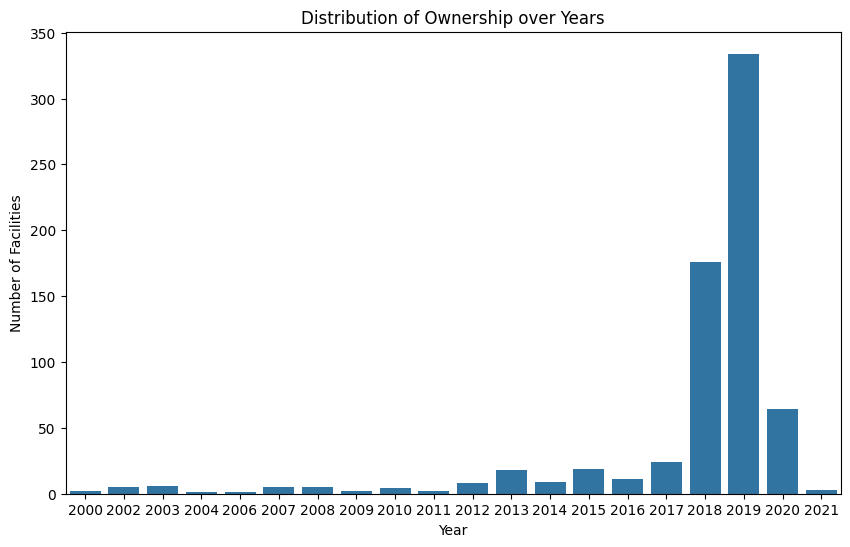

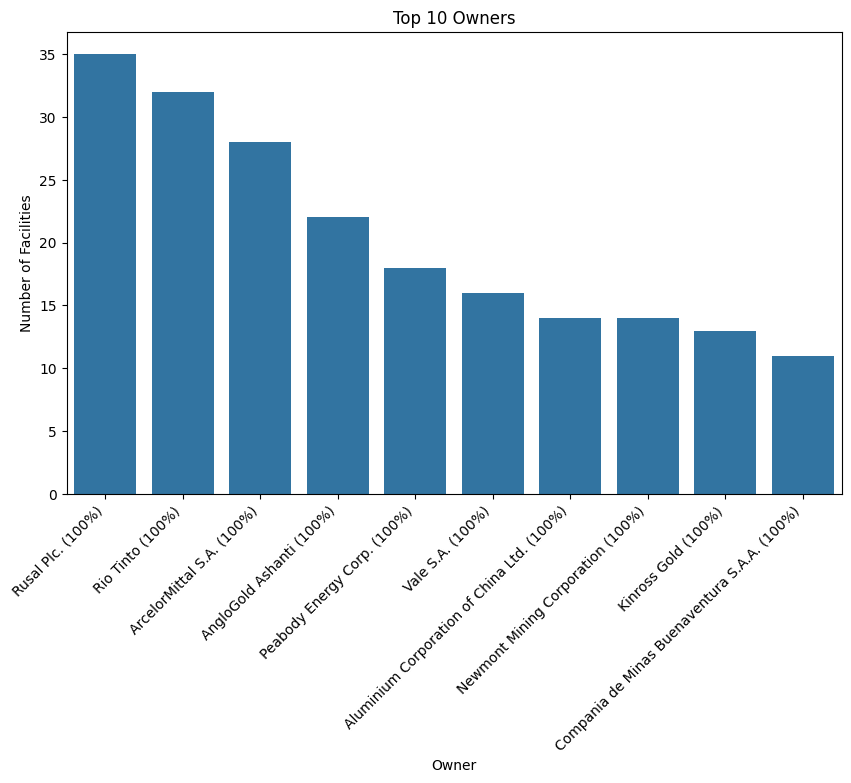

In [ ]:
# prompt: perform some visualization on the ownership dataframe withe the following columns: id	facility_id	year	owners	operators	source_id	comment

import matplotlib.pyplot as plt
import seaborn as sns

# Assuming 'ownership' DataFrame is already loaded as shown in the previous code

# 1. Distribution of Ownership over Years
plt.figure(figsize=(10, 6))
sns.countplot(x='year', data=ownership)
plt.title('Distribution of Ownership over Years')
plt.xlabel('Year')
plt.ylabel('Number of Facilities')
plt.show()

# 2. Top Owners
top_owners = ownership['owners'].value_counts().head(10)  # Adjust the number (10) as needed
plt.figure(figsize=(10, 6))
sns.barplot(x=top_owners.index, y=top_owners.values)
plt.title('Top 10 Owners')
plt.xlabel('Owner')
plt.ylabel('Number of Facilities')
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for better readability
plt.show()

# # 3. Ownership by Operator (if applicable and meaningful)
# if 'operators' in ownership.columns:
#     plt.figure(figsize=(12, 6))
#     sns.countplot(x='operators', data=ownership, order=ownership['operators'].value_counts().index) # order by frequency
#     plt.title('Ownership by Operator')
#     plt.xlabel('Operator')
#     plt.ylabel('Number of Facilities')
#     plt.xticks(rotation=90) # Rotate labels 90 degrees
#     plt.show()

# # 4.  Relationship between year and number of owners (if meaningful)
# plt.figure(figsize=(10, 6))
# sns.lineplot(x='year', y='owners', data=ownership)
# plt.title('Ownership Trend Over Years')
# plt.xlabel('Year')
# plt.ylabel('Number of Owners')
# plt.show()



In [ ]:
ownership['operators'].unique()

# ownership[ownership['operators']=="Kinross Gold"]

array([nan, 'Compañía Minera Antamina S.A.', 'BHP',
       'Compania de Minas Buenaventura S.A.A.', 'Kinross Gold',
       'Rio Tinto', 'Assmang Proprietary Ltd.',
       'BHP Mitsubishi Alliance (BMA)', 'Chalco Guinea Company S.A.',
       'Boggabri Coal Operations Pty Ltd (BCOPL)', 'Sierra Metals Inc.',
       'Bulga Coal Management Pty Ltd', 'Cerrejon',
       'Hindustan Zinc Limited',
       'Mineração Maracá Indústria e Comércio S/A', 'Alcoa Corp.',
       'Platinum Group Metals Corporation',
       'PT Nusa Halmahera Minerals (Newcrest Mining Limited 75%)',
       'PT Freeport Indonesia', 'Aluminium Corporation of China Ltd.',
       'Whitehaven Coal Ltd.', 'ArcelorMittal S.A.',
       'Hunter Valley Operations Joint Venture',
       'Iron Ore Company of Canada Inc.',
       'Jacobina Mineração e Comércio S. A. (JMC)', 'PAO Severstal',
       'Luossavaara-Kiirunavaara AB',
       'Minera Barrick Misquichilca S.A. (MBM)', 'MMG', 'Impala Platinum',
       'African Rainbow Minerals 

In [ ]:
print("year:", len(ownership['year'].unique()))
print("owners:", len(ownership['owners'].unique()))
print("facilities:", len(ownership['facility_id'].unique()))
print("source_id:", len(ownership['source_id'].unique()))


year: 20
owners: 290
facilities: 667
source_id: 195


## **Minerals**

In [ ]:
print(f"Shape: {minerals.shape}\n")
minerals.head()

Shape: (12292, 12)



,id,facility_id,year,type,material,value_tonnes,overall_grade_ppm,amount_sold_tonnes,mine_processing,reporting_period,source_id,comment
0,1,COM00001.00,2013,Ore mined,O.bulk,1625532,NaN,NaN,NaN,NaN,det_1729,NaN
1,2,COM00001.00,2013,Ore processed,O.bulk,1625532,NaN,NaN,NaN,NaN,det_1729,NaN
2,3,COM00001.00,2014,Ore mined,O.bulk,1452933,NaN,NaN,NaN,NaN,det_1729,NaN
3,4,COM00001.00,2014,Ore processed,O.bulk,1452933,NaN,NaN,NaN,NaN,det_1729,NaN
4,5,COM00001.00,2015,Ore mined,O.bulk,1235053,NaN,NaN,NaN,NaN,det_1730,NaN


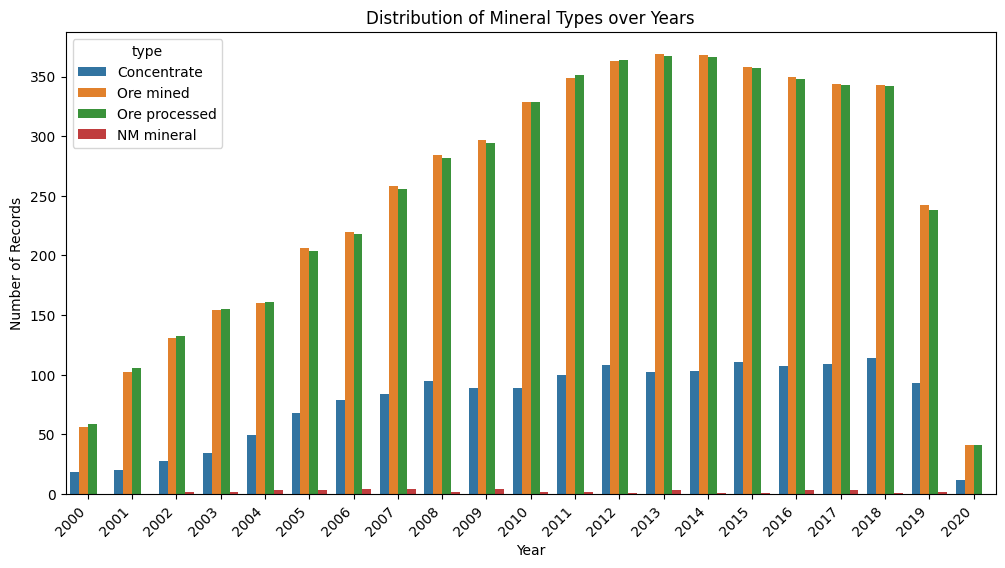

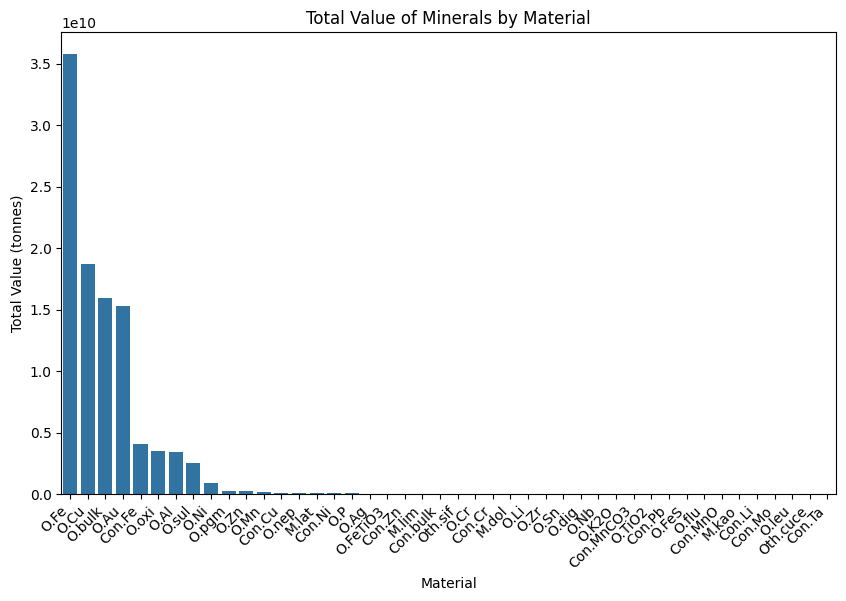

In [ ]:
# prompt: perform some visualization on the minerals dataframe with the the following columns: id	facility_id	year	type	material	value_tonnes

# Assuming 'minerals' DataFrame is already loaded

# 1. Distribution of Mineral Types over Years
plt.figure(figsize=(12, 6))
sns.countplot(x='year', hue='type', data=minerals)
plt.title('Distribution of Mineral Types over Years')
plt.xlabel('Year')
plt.ylabel('Number of Records')
plt.xticks(rotation=45, ha='right')
plt.show()

# 2. Total Value of Minerals by Material
material_value = minerals.groupby('material')['value_tonnes'].sum().sort_values(ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(x=material_value.index, y=material_value.values)
plt.title('Total Value of Minerals by Material')
plt.xlabel('Material')
plt.ylabel('Total Value (tonnes)')
plt.xticks(rotation=45, ha='right')
plt.show()

# # 3.  Mineral Production Trend Over Years for Specific Material (e.g., Gold)
# # Replace 'Gold' with the material of your interest
# material_of_interest = 'Gold' #@param {type:"string"}
# if material_of_interest in minerals['material'].unique():
#     specific_material = minerals[minerals['material'] == material_of_interest]
#     plt.figure(figsize=(10, 6))
#     sns.lineplot(x='year', y='value_tonnes', data=specific_material)
#     plt.title(f'Production Trend of {material_of_interest} Over Years')
#     plt.xlabel('Year')
#     plt.ylabel('Value (tonnes)')
#     plt.show()
# else:
#     print(f"Material '{material_of_interest}' not found in the dataset.")


In [ ]:
print(minerals.isna().sum())

id                        0
facility_id               0
year                      0
type                      0
material                  0
value_tonnes              0
overall_grade_ppm     11884
amount_sold_tonnes    11750
mine_processing       11809
reporting_period      10332
source_id                 0
comment               11637
dtype: int64


In [ ]:
print("Types:" , len(minerals['type'].unique()))
print("Materials:" , len(minerals['material'].unique()))

Types: 4
Materials: 44


# **Testing**

In [ ]:
# Merge commodities and minerals
merged_data = pd.merge(commodities, minerals, left_on='id_minerals', right_on='id', how='left', suffixes=('_commodities', '_minerals'))

# Display merged data info
print(merged_data.info())
print(merged_data.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9426 entries, 0 to 9425
Data columns (total 28 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id_commodities                  9426 non-null   int64  
 1   facility_id_commodities         9426 non-null   object 
 2   year_commodities                9426 non-null   int64  
 3   material_commodities            8895 non-null   object 
 4   commodity                       9426 non-null   object 
 5   value_tonnes_commodities        9399 non-null   float64
 6   grade_ppm                       7132 non-null   float64
 7   recovery_rate                   5497 non-null   float64
 8   yield_ppm                       127 non-null    float64
 9   amount_sold_tonnes_commodities  1423 non-null   float64
 10  metal_payable_tonnes            429 non-null    float64
 11  mine_processing_commodities     473 non-null    object 
 12  reporting_period_commodities    12

In [ ]:
# prompt: check if year_commodities, year_minerals in merged_data has the same values accross all rows

# Check if 'year_commodities' and 'year_minerals' have the same values across all rows
if 'year_commodities' in merged_data.columns and 'year_minerals' in merged_data.columns:
    if merged_data['year_commodities'].equals(merged_data['year_minerals']):
        print("'year_commodities' and 'year_minerals' have the same values across all rows.")
    else:
        print("'year_commodities' and 'year_minerals' do not have the same values across all rows.")
        # Further analysis: Find the rows where they differ
        diff_rows = merged_data[merged_data['year_commodities'] != merged_data['year_minerals']]
        print("\nRows with differing values:")
        print(diff_rows[['year_commodities', 'year_minerals']])
else:
    print("One or both of 'year_commodities' and 'year_minerals' columns are not found in the merged dataset.")

'year_commodities' and 'year_minerals' do not have the same values across all rows.

Rows with differing values:
      year_commodities  year_minerals
90                2006            NaN
251               2001            NaN
252               2001            NaN
253               2002            NaN
254               2002            NaN
...                ...            ...
9409              2015            NaN
9413              2016            NaN
9417              2017            NaN
9421              2018            NaN
9425              2019            NaN

[2373 rows x 2 columns]


In [ ]:
merged_data['year_commodities'].isna().sum()

0

In [ ]:
import numpy as np
merged_data['year_commodities'] = pd.to_datetime(merged_data['year_commodities'], format='%Y') #Convert to datetime
merged_data['year'] = merged_data['year_commodities'].dt.year #Extract year as integer

merged_data['year_sin'] = np.sin(2 * np.pi * merged_data['year'] / merged_data['year'].max())
merged_data['year_cos'] = np.cos(2 * np.pi * merged_data['year'] / merged_data['year'].max())

In [ ]:
# prompt: check if facility_id_commodities, facility_id_minerals in merged_data has the same values accross all rows

# Check if 'facility_id_commodities' and 'facility_id_minerals' have the same values across all rows
if 'facility_id_commodities' in merged_data.columns and 'facility_id_minerals' in merged_data.columns:
    if merged_data['facility_id_commodities'].equals(merged_data['facility_id_minerals']):
        print("'facility_id_commodities' and 'facility_id_minerals' have the same values across all rows.")
    else:
        print("'facility_id_commodities' and 'facility_id_minerals' do not have the same values across all rows.")
        # Further analysis: Find the rows where they differ
        diff_rows = merged_data[merged_data['facility_id_commodities'] != merged_data['facility_id_minerals']]
        print("\nRows with differing values:")
        print(diff_rows[['facility_id_commodities', 'facility_id_minerals']])
else:
    print("One or both of 'facility_id_commodities' and 'facility_id_minerals' columns are not found in the merged dataset.")

'facility_id_commodities' and 'facility_id_minerals' do not have the same values across all rows.

Rows with differing values:
     facility_id_commodities facility_id_minerals
90               COM00009.00                  NaN
251              COM00031.00                  NaN
252              COM00031.00                  NaN
253              COM00031.00                  NaN
254              COM00031.00                  NaN
...                      ...                  ...
9409             COM01432.00                  NaN
9413             COM01432.00                  NaN
9417             COM01432.00                  NaN
9421             COM01432.00                  NaN
9425             COM01432.00                  NaN

[2373 rows x 2 columns]


In [ ]:
# prompt: check if material_commodities, material_minerals in merged_data has the same values accross all rows

# Check if 'material_commodities' and 'material_minerals' have the same values across all rows
if 'material_commodities' in merged_data.columns and 'material_minerals' in merged_data.columns:
    if merged_data['material_commodities'].equals(merged_data['material_minerals']):
        print("'material_commodities' and 'material_minerals' have the same values across all rows.")
    else:
        print("'material_commodities' and 'material_minerals' do not have the same values across all rows.")
        # Further analysis: Find the rows where they differ
        diff_rows = merged_data[merged_data['material_commodities'] != merged_data['material_minerals']]
        print("\nRows with differing values:")
        print(diff_rows[['material_commodities', 'material_minerals']])
else:
    print("One or both of 'material_commodities' and 'material_minerals' columns are not found in the merged dataset.")

'material_commodities' and 'material_minerals' do not have the same values across all rows.

Rows with differing values:
     material_commodities material_minerals
90                   O.Au               NaN
251                O.bulk               NaN
252                O.bulk               NaN
253                O.bulk               NaN
254                O.bulk               NaN
...                   ...               ...
9409                  NaN               NaN
9413                  NaN               NaN
9417                  NaN               NaN
9421                  NaN               NaN
9425                  NaN               NaN

[2373 rows x 2 columns]


In [ ]:
merged_data['facility_id']= merged_data['facility_id_commodities']
merged_data['material']= merged_data['material_commodities']

In [ ]:
merged_data.columns

Index(['id_commodities', 'facility_id_commodities', 'year_commodities',
       'material_commodities', 'commodity', 'value_tonnes_commodities',
       'grade_ppm', 'recovery_rate', 'yield_ppm',
       'amount_sold_tonnes_commodities', 'metal_payable_tonnes',
       'mine_processing_commodities', 'reporting_period_commodities',
       'source_id_commodities', 'comment_commodities', 'id_minerals',
       'id_minerals', 'facility_id_minerals', 'year_minerals', 'type',
       'material_minerals', 'value_tonnes_minerals', 'overall_grade_ppm',
       'amount_sold_tonnes_minerals', 'mine_processing_minerals',
       'reporting_period_minerals', 'source_id_minerals', 'comment_minerals',
       'year', 'year_sin', 'year_cos', 'facility_id'],
      dtype='object')

In [ ]:
merged_data = pd.merge(merged_data, reserves, on=['facility_id', 'year', 'material', 'commodity'], how='left', suffixes=('', '_reserves'))
merged_data = pd.merge(merged_data, processing, on=['facility_id', 'year'], how='left', suffixes=('', '_processing'))
merged_data = pd.merge(merged_data, capacity, on=['facility_id', 'year', 'material', 'commodity'], how='left', suffixes=('', '_capacity'))

In [ ]:
print(merged_data.shape)
print(merged_data.isna().sum())

(9775, 57)
id_commodities                        0
facility_id_commodities               0
year_commodities                      0
material_commodities                606
commodity                             0
value_tonnes_commodities             27
grade_ppm                          2369
recovery_rate                      4008
yield_ppm                          9648
amount_sold_tonnes_commodities     8348
metal_payable_tonnes               9346
mine_processing_commodities        9227
reporting_period_commodities       8542
source_id_commodities                 0
comment_commodities                9389
id_minerals                        2523
id_minerals                        2523
facility_id_minerals               2523
year_minerals                      2523
type                               2523
material_minerals                  2523
value_tonnes_minerals              2523
overall_grade_ppm                  9545
amount_sold_tonnes_minerals        9684
mine_processing_minerals     

In [ ]:
# check missing values in this columns
columns =['value_tonnes_commodities','mineral_value_tonnes', 'commodity_value_tonnes', 'input_value_tonnes', 'output_value_tonnes', 'value_tpa']

merged_data[columns].isna().sum()

,0
value_tonnes_commodities,27
mineral_value_tonnes,9432
commodity_value_tonnes,9576
input_value_tonnes,9686
output_value_tonnes,9279
value_tpa,9775


In [ ]:
# prompt: sort total number of missing data in merhed_data

# Sort the total number of missing data in merged_data for specified columns
columns = ['value_tonnes_commodities', 'mineral_value_tonnes', 'commodity_value_tonnes', 'input_value_tonnes', 'output_value_tonnes', 'value_tpa']
missing_data_counts = merged_data.isna().sum().sort_values(ascending=True)
missing_data_counts

,0
id_commodities,0
facility_id,0
year_cos,0
year_sin,0
source_id_commodities,0
year,0
facility_id_commodities,0
year_commodities,0
commodity,0
value_tonnes_commodities,27


In [ ]:
print(waste.shape, "\n")
print(waste.isna().sum(), "\n")

print(minerals.shape, "\n")
print(minerals.isna().sum(), "\n")

print(processing.shape, "\n")
print(processing.isna().sum(), "\n")


(1119, 13) 

id                          0
facility_id                 0
year                        0
type_mining               902
waste_type                399
material                  879
commodity                1039
value_tonnes              369
total_material_tonnes     611
stripping_ratio           914
reporting_period          887
source_id                   0
comment                  1106
dtype: int64 

(12292, 12) 

id                        0
facility_id               0
year                      0
type                      0
material                  0
value_tonnes              0
overall_grade_ppm     11884
amount_sold_tonnes    11750
mine_processing       11809
reporting_period      10332
source_id                 0
comment               11637
dtype: int64 

(3979, 16) 

id                         0
facility_id                0
facility_type              0
year                       0
input                   1871
input_value_tonnes      3481
output                   297
o

In [ ]:
# print("waste:" , waste.columns)
# print("processing:" , processing.columns)
# print("minerals:" , minerals.columns)

#columns they have in common
print("columns they have in common:" , set(waste.columns) & set(minerals.columns))
print("columns they have in common:" , set(waste.columns) & set(processing.columns))
print("columns they have in common:" , set(processing.columns) & set(minerals.columns))


columns they have in common: {'material', 'facility_id', 'reporting_period', 'value_tonnes', 'source_id', 'year', 'comment', 'id'}
columns they have in common: {'facility_id', 'reporting_period', 'source_id', 'year', 'comment', 'id'}
columns they have in common: {'facility_id', 'reporting_period', 'amount_sold_tonnes', 'source_id', 'year', 'comment', 'id'}


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import seaborn as sns
import matplotlib.pyplot as plt



def analyze_missing_across_tables(waste, minerals, processing):
    """Analyze common columns and their missing values across tables"""
    # Get common columns
    common_cols = []
    all_cols = set(waste.columns) | set(minerals.columns) | set(processing.columns)

    for col in all_cols:
        tables_present = []
        missing_stats = []

        if col in waste.columns:
            missing_pct = (waste[col].isna().sum() / len(waste)) * 100
            tables_present.append('waste')
            missing_stats.append(f"Waste: {missing_pct:.1f}%")

        if col in minerals.columns:
            missing_pct = (minerals[col].isna().sum() / len(minerals)) * 100
            tables_present.append('minerals')
            missing_stats.append(f"Minerals: {missing_pct:.1f}%")

        if col in processing.columns:
            missing_pct = (processing[col].isna().sum() / len(processing)) * 100
            tables_present.append('processing')
            missing_stats.append(f"Processing: {missing_pct:.1f}%")

        if len(tables_present) > 1:
            print(f"\nColumn '{col}' present in: {', '.join(tables_present)}")
            print("Missing values:", ', '.join(missing_stats))

def initial_exploration(df, table_name):
    """Perform initial exploration of a dataframe"""
    print(f"\n{table_name} Dataset Summary:")
    print("-" * 50)

    # Basic info
    print("\nDataset Info:")
    print(f"Shape: {df.shape}")
    print(f"Number of unique facilities: {df['facility_id'].nunique()}")
    print(f"Year range: {df['year'].min()} - {df['year'].max()}")

    # Missing values
    missing = df.isnull().sum()
    missing_pct = (missing / len(df)) * 100
    missing_info = pd.DataFrame({
        'Missing Values': missing,
        'Percentage': missing_pct
    }).sort_values('Missing Values', ascending=False)

    print("\nMissing Values Summary:")
    print(missing_info[missing_info['Missing Values'] > 0])

    return missing_info

# Main execution
if __name__ == "__main__":


    # Analyze missing values across tables
    print("\nAnalyzing common columns across tables:")
    analyze_missing_across_tables(waste, minerals, processing)

    # Perform initial exploration
    waste_missing = initial_exploration(waste, "Waste")
    minerals_missing = initial_exploration(minerals, "Minerals")
    processing_missing = initial_exploration(processing, "Processing")


Analyzing common columns across tables:

Column 'facility_id' present in: waste, minerals, processing
Missing values: Waste: 0.0%, Minerals: 0.0%, Processing: 0.0%

Column 'reporting_period' present in: waste, minerals, processing
Missing values: Waste: 79.3%, Minerals: 84.1%, Processing: 87.1%

Column 'year' present in: waste, minerals, processing
Missing values: Waste: 0.0%, Minerals: 0.0%, Processing: 0.0%

Column 'id' present in: waste, minerals, processing
Missing values: Waste: 0.0%, Minerals: 0.0%, Processing: 0.0%

Column 'material' present in: waste, minerals
Missing values: Waste: 78.6%, Minerals: 0.0%

Column 'amount_sold_tonnes' present in: minerals, processing
Missing values: Minerals: 95.6%, Processing: 95.5%

Column 'value_tonnes' present in: waste, minerals
Missing values: Waste: 33.0%, Minerals: 0.0%

Column 'source_id' present in: waste, minerals, processing
Missing values: Waste: 0.0%, Minerals: 0.0%, Processing: 0.0%

Column 'comment' present in: waste, minerals, p

In [ ]:
import pandas as pd
import numpy as np

def validate_common_fields(waste, minerals, processing):
    """
    Validate common fields across datasets to ensure consistency
    """
    # List of common columns we found
    common_cols = {
        'all_tables': ['facility_id', 'year', 'id', 'reporting_period', 'source_id', 'comment'],
        'waste_minerals': ['material', 'value_tonnes'],
        'minerals_processing': ['amount_sold_tonnes']
    }

    print("\n=== Validation of Common Fields ===")

    # 1. Validate value ranges for numeric fields
    print("\n1. Numeric Fields Range Comparison:")
    for col in ['year', 'facility_id']:
        print(f"\n{col} ranges:")
        print(f"Waste: {waste[col].min()} - {waste[col].max()}")
        print(f"Minerals: {minerals[col].min()} - {minerals[col].max()}")
        print(f"Processing: {processing[col].min()} - {processing[col].max()}")

    # 2. Check for facility_id consistency
    print("\n2. Facility ID Analysis:")
    waste_facilities = set(waste['facility_id'])
    minerals_facilities = set(minerals['facility_id'])
    processing_facilities = set(processing['facility_id'])

    print(f"Unique facilities in Waste: {len(waste_facilities)}")
    print(f"Unique facilities in Minerals: {len(minerals_facilities)}")
    print(f"Unique facilities in Processing: {len(processing_facilities)}")
    print(f"Facilities in all three tables: {len(waste_facilities & minerals_facilities & processing_facilities)}")

    # 3. Compare value_tonnes between waste and minerals
    print("\n3. Value_tonnes Comparison (Waste vs Minerals):")
    merged_values = pd.merge(
        waste[['facility_id', 'year', 'value_tonnes']],
        minerals[['facility_id', 'year', 'value_tonnes']],
        on=['facility_id', 'year'],
        suffixes=('_waste', '_minerals'),
        how='inner'
    )
    if not merged_values.empty:
        print(f"Number of matching facility-year pairs: {len(merged_values)}")
        print("\nSample of matching values:")
        print(merged_values.head())
    else:
        print("No matching facility-year pairs found")

    # 4. Check reporting_period formats
    print("\n4. Reporting Period Format Analysis:")
    for df, name in [(waste, 'Waste'), (minerals, 'Minerals'), (processing, 'Processing')]:
        if 'reporting_period' in df.columns:
            print(f"\n{name} reporting_period unique values:")
            print(df['reporting_period'].value_counts().head())

    # 5. Material field comparison between waste and minerals
    print("\n5. Material Field Analysis (Waste vs Minerals):")
    if 'material' in waste.columns and 'material' in minerals.columns:
        waste_materials = set(waste['material'].dropna().unique())
        minerals_materials = set(minerals['material'].dropna().unique())
        print(f"Unique materials in Waste: {len(waste_materials)}")
        print(f"Unique materials in Minerals: {len(minerals_materials)}")
        print(f"Common materials: {len(waste_materials & minerals_materials)}")
        print("\nSample of common materials:")
        print(list(waste_materials & minerals_materials)[:5])


validate_common_fields(waste, minerals, processing)


=== Validation of Common Fields ===

1. Numeric Fields Range Comparison:

year ranges:
Waste: 2000 - 2020
Minerals: 2000 - 2020
Processing: 2000 - 2019

facility_id ranges:
Waste: COM00009.00 - COM01388.00
Minerals: COM00001.00 - COM01435.00
Processing: COM00005.00 - COM01435.00

2. Facility ID Analysis:
Unique facilities in Waste: 144
Unique facilities in Minerals: 570
Unique facilities in Processing: 225
Facilities in all three tables: 6

3. Value_tonnes Comparison (Waste vs Minerals):
Number of matching facility-year pairs: 1866

Sample of matching values:
   facility_id  year  value_tonnes_waste  value_tonnes_minerals
0  COM00009.00  2007          32035046.4                8094946
1  COM00009.00  2007          32035046.4                7339248
2  COM00009.00  2008          34772976.0               11101406
3  COM00009.00  2008          34772976.0                7495286
4  COM00009.00  2009          36731620.8               10416470

4. Reporting Period Format Analysis:

Waste repo

In [ ]:
minerals.isna().sum()

,0
id,0
facility_id,0
year,0
type,0
material,0
value_tonnes,0
overall_grade_ppm,11884
amount_sold_tonnes,11750
mine_processing,11809
reporting_period,10332


In [ ]:
from re import X
import pandas as pd
import numpy as np
import GPy
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

def load_and_preprocess(waste, minerals):
    """
    Load and preprocess the waste and minerals datasets
    """


    # Create facility-level features from minerals data
    facility_minerals = create_facility_features(minerals)

    # Preprocess waste data
    waste_processed = preprocess_waste(waste)
    print("waste_processed:", waste_processed.shape)
    print("facility_minerals:", facility_minerals.shape)

    # Merge waste with facility-level features
    final_df = pd.merge(waste_processed, facility_minerals,
                       on='facility_id', how='left')

    return final_df

def create_facility_features(minerals):
    """
    Create facility-level aggregated features from minerals data
    """
    # Calculate facility-level aggregations
    facility_features = minerals.groupby('facility_id').agg({
        'value_tonnes': ['mean', 'std', 'max'],
        'material': 'nunique',
        'year': ['min', 'max']
    }).reset_index()

    # Flatten column names
    facility_features.columns = ['facility_id',
                               'avg_mineral_tonnes',
                               'std_mineral_tonnes',
                               'max_mineral_tonnes',
                               'unique_materials',
                               'first_year',
                               'last_year']

    # Calculate operation duration
    facility_features['operation_years'] = (
        facility_features['last_year'] - facility_features['first_year'] + 1
    )

    return facility_features

def preprocess_waste(waste):
    """
    Preprocess waste dataset
    """
    df = waste.copy()

    # Handle missing values in waste_type and type_mining
    for col in ['waste_type', 'type_mining']:
        df[col] = df[col].fillna('Unknown')

    # Create binary flags for material types
    materials = pd.get_dummies(df['material'], prefix='material', dummy_na=True)
    df = pd.concat([df, materials], axis=1)

    # Extract year-based features
    df['years_operation'] = df.groupby('facility_id')['year'].transform(
        lambda x: x - x.min() + 1
    )

    # Create reporting period features
    df['reporting_period'] = df['reporting_period'].fillna('Unknown')
    reporting_period_dummies = pd.get_dummies(
        df['reporting_period'],
        prefix='reporting'
    )
    df = pd.concat([df, reporting_period_dummies], axis=1)

    # Select relevant columns
    keep_cols = ['facility_id', 'year', 'value_tonnes', 'years_operation'] + \
                [col for col in df.columns if col.startswith(('material_', 'reporting_'))]

    return df[keep_cols]

def prepare_model_data(df, target_col='value_tonnes'):
    """
    Prepare data for modeling
    """

    df.dropna(inplace=True)
    # print(df.info())
    # Separate features and target
    X = df.drop([target_col, 'facility_id', 'reporting_period'], axis=1)
    y = df[target_col]

    # Handle missing values in target
    mask = y.notna()
    X = X[mask]
    y = y[mask]

    # Split data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    # Scale features
    scaler = MinMaxScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    return X_train_scaled, X_test_scaled, y_train, y_test, scaler, X_train

def train_and_evaluate():
    """
    Train and evaluate the baseline model
    """
    # Load and preprocess data
    final_df = load_and_preprocess(waste, minerals)

    # print(final_df.isna().sum())
    # print(final_df.shape)

    # Prepare data for modeling
    X_train_scaled, X_test_scaled, y_train, y_test, scaler, X_train = prepare_model_data(
        final_df
    )

    # Train baseline model
    rf_model = RandomForestRegressor(
        n_estimators=100,
        max_depth=10,
        random_state=42
    )

    # Fit model
    rf_model.fit(X_train_scaled, y_train)

    # Make predictions
    train_pred = rf_model.predict(X_train_scaled)
    test_pred = rf_model.predict(X_test_scaled)

    # Calculate metrics
    metrics = {
        'Train R2': r2_score(y_train, train_pred),
        'Test R2': r2_score(y_test, test_pred),
        'Train RMSE': np.sqrt(mean_squared_error(y_train, train_pred)),
        'Train NRMSE': np.sqrt(mean_squared_error(y_train, train_pred)) / y_train.std(),
        'Test RMSE': np.sqrt(mean_squared_error(y_test, test_pred)),
        'Train MAE': mean_absolute_error(y_train, train_pred),
        'Test MAE': mean_absolute_error(y_test, test_pred),
        'Test NRMSE': np.sqrt(mean_squared_error(y_test, test_pred)) / y_test.std()
    }


    # Feature importance
    feature_importance = pd.DataFrame({
        'feature': X_train.columns,
        'importance': rf_model.feature_importances_
    }).sort_values('importance', ascending=False)

    return metrics, feature_importance, rf_model

def train_and_evaluate_xgboost():
  """
  Train and evaluate the XGBoost model
  """
  # Load and preprocess data
  final_df = load_and_preprocess(waste, minerals)

  # Prepare data for modeling
  X_train_scaled, X_test_scaled, y_train, y_test, scaler, X_train = prepare_model_data(
      final_df
  )

  #Train an optimized XGB model
  xgb = XGBRegressor(n_estimators=500, learning_rate=0.08, max_depth=10, random_state=42)
  xgb.fit(X_train_scaled, y_train)


  #Make predictions
  train_pred = xgb.predict(X_train_scaled)
  test_pred = xgb.predict(X_test_scaled)





  # Calculate metrics
  metrics = {
      'Train R2': r2_score(y_train, train_pred),
      'Test R2': r2_score(y_test, test_pred),
      'Train RMSE': np.sqrt(mean_squared_error(y_train, train_pred)),
      'Train NRMSE': np.sqrt(mean_squared_error(y_train, train_pred)) / y_train.std(),
      'Test RMSE': np.sqrt(mean_squared_error(y_test, test_pred)),
      'Train MAE': mean_absolute_error(y_train, train_pred),
      'Test MAE': mean_absolute_error(y_test, test_pred),
      'Test NRMSE': np.sqrt(mean_squared_error(y_test, test_pred)) / y_test.std()
  }

  #feature relevance
  feature_importance = pd.DataFrame({
      'feature': X_train.columns,
      'importance': xgb.feature_importances_
  }).sort_values('importance', ascending=False)

  return metrics, feature_importance, xgb



if __name__ == "__main__":
    # Train and evaluate model
    metrics, feature_importance, model = train_and_evaluate()

    # Print results
    print("\nModel Performance Metrics:")
    for metric, value in metrics.items():
        print(f"{metric}: {value:.4f}")

    # print("\nTop 10 Most Important Features:")
    # print(feature_importance.head(10))

    print("\n+++++++++++++XGBOOST++++++++++++\n")
    metrics, feature_importance, model = train_and_evaluate_xgboost()
     # Print results
    print("\nModel Performance Metrics:")
    for metric, value in metrics.items():
        print(f"{metric}: {value:.4f}")

    print("\nTop 10 Most Important Features:")
    print(feature_importance.head(10))

waste_processed: (1119, 14)
facility_minerals: (570, 8)

Model Performance Metrics:
Train R2: 0.9603
Test R2: 0.8202
Train RMSE: 6815032.9436
Train NRMSE: 0.1989
Test RMSE: 13286817.3189
Train MAE: 3447957.2276
Test MAE: 6730033.6015
Test NRMSE: 0.4212

+++++++++++++XGBOOST++++++++++++

waste_processed: (1119, 14)
facility_minerals: (570, 8)

Model Performance Metrics:
Train R2: 0.9957
Test R2: 0.9003
Train RMSE: 2231919.5962
Train NRMSE: 0.0651
Test RMSE: 9896109.5814
Train MAE: 308061.6863
Test MAE: 6159556.0804
Test NRMSE: 0.3137

Top 10 Most Important Features:
               feature  importance
11  avg_mineral_tonnes    0.306713
17     operation_years    0.243424
15          first_year    0.224420
13  max_mineral_tonnes    0.140593
14    unique_materials    0.034973
12  std_mineral_tonnes    0.015179
0                 year    0.014644
1      years_operation    0.014124
16           last_year    0.004532
5        material_O.Cu    0.000417


# **Operational Efficiency Analysis**

In [ ]:
print("Commodities\n", commodities.shape, "\n", commodities.isna().sum())
print("\nMinerals\n", minerals.shape, "\n" ,minerals.isna().sum())
print("\nProcessing\n",processing.shape, "\n" , processing.isna().sum())
print("\nTransport\n",capacity.shape, "\n" , capacity.isna().sum())

Commodities
 (9426, 39) 
 id                        0
facility_id               0
year                      0
material                215
value_tonnes              0
grade_ppm                63
recovery_rate           260
amount_sold_tonnes     8003
reporting_period       8193
source_id                 0
id_minerals            2373
commodity_Me.Ag           0
commodity_Me.Al2O3        0
commodity_Me.Au           0
commodity_Me.Co           0
commodity_Me.Cu           0
commodity_Me.Fe           0
commodity_Me.Ir           0
commodity_Me.Li2O         0
commodity_Me.Mn           0
commodity_Me.Mo           0
commodity_Me.Na_nec       0
commodity_Me.Nb           0
commodity_Me.Ni           0
commodity_Me.Pb           0
commodity_Me.Pd           0
commodity_Me.Pt           0
commodity_Me.Rh           0
commodity_Me.Ru           0
commodity_Me.Sb           0
commodity_Me.Sn           0
commodity_Me.Ta2O5        0
commodity_Me.Te           0
commodity_Me.U3O8         0
commodity_Me.Zn       

In [ ]:
# Step 1: Data Loading and Initial Processing
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# Load datasets
processing_df = processing
commodities_df = commodities
minerals_df = minerals

# Step 2: Calculate Key Efficiency Metrics
def calculate_efficiency_metrics(df):
    df['conversion_efficiency'] = df['output_value_tonnes'] / df['input_value_tonnes']
    return df

# Step 3: Facility Performance Analysis
def analyze_facility_performance(df):
    facility_metrics = df.groupby('facility_id').agg({
        'conversion_efficiency': ['mean', 'std'],
        'grade_ppm': ['mean', 'std'],
        'input_value_tonnes': 'sum',
        'output_value_tonnes': 'sum'
    })
    return facility_metrics

# Step 4: Time Series Analysis
def analyze_temporal_trends(df):
    yearly_metrics = df.groupby(['year', 'facility_type']).agg({
        'conversion_efficiency': 'mean',
        'grade_ppm': 'mean'
    })
    return yearly_metrics

In [ ]:
# Import required libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler



# Step 1: Calculate Basic Efficiency Metrics
def calculate_basic_metrics(df):
    metrics_df = df.copy()

    # Conversion Efficiency (Output/Input ratio)
    metrics_df['conversion_efficiency'] = metrics_df['output_value_tonnes'] / metrics_df['input_value_tonnes']

    # Material Loss Rate
    metrics_df['material_loss'] = 1 - metrics_df['conversion_efficiency']

    # Processing Intensity (input processed per facility type)
    facility_type_avg = metrics_df.groupby('facility_type')['input_value_tonnes'].transform('mean')
    metrics_df['processing_intensity'] = metrics_df['input_value_tonnes'] / facility_type_avg

    return metrics_df

# Step 2: Create Grade-Based Efficiency Metrics
def calculate_grade_metrics(df):
    # Grade Efficiency (output grade vs input grade)
    df['grade_efficiency'] = df['grade_ppm'] / df['grade_ppm'].mean()

    # Grade-Adjusted Efficiency
    df['grade_adjusted_efficiency'] = df['conversion_efficiency'] * df['grade_efficiency']

    return df

# Step 3: Calculate Facility-Level KPIs
def calculate_facility_kpis(df):
    facility_kpis = df.groupby('facility_id').agg({
        'conversion_efficiency': ['mean', 'std', 'min', 'max'],
        'grade_ppm': ['mean', 'std'],
        'input_value_tonnes': 'sum',
        'output_value_tonnes': 'sum',
        'material_loss': 'mean',
        'processing_intensity': 'mean'
    }).round(4)

    # Calculate facility utilization trend
    facility_kpis['throughput_stability'] = 1 - facility_kpis[('conversion_efficiency', 'std')]

    return facility_kpis

# Step 4: Time-Based Efficiency Analysis
def analyze_temporal_efficiency(df):
    temporal_metrics = df.groupby(['year', 'facility_type']).agg({
        'conversion_efficiency': 'mean',
        'material_loss': 'mean',
        'grade_ppm': 'mean',
        'processing_intensity': 'mean'
    }).round(4)

    return temporal_metrics

# Execute the analysis
try:
    # Calculate all metrics
    efficiency_df = calculate_basic_metrics(processing_df)
    efficiency_df = calculate_grade_metrics(efficiency_df)

    # Calculate KPIs
    facility_kpis = calculate_facility_kpis(efficiency_df)
    temporal_metrics = analyze_temporal_efficiency(efficiency_df)

    # Basic statistics for the metrics
    print("\nOverall Efficiency Metrics:")
    print(efficiency_df[['conversion_efficiency', 'material_loss', 'grade_efficiency']].describe())

    # Facility type performance
    print("\nEfficiency by Facility Type:")
    print(efficiency_df.groupby('facility_type')['conversion_efficiency'].describe())

    # Identify top and bottom performing facilities
    top_facilities = facility_kpis.nlargest(5, ('conversion_efficiency', 'mean'))
    bottom_facilities = facility_kpis.nsmallest(5, ('conversion_efficiency', 'mean'))

    print("\nTop 5 Performing Facilities:")
    print(top_facilities[('conversion_efficiency', 'mean')])

    print("\nBottom 5 Performing Facilities:")
    print(bottom_facilities[('conversion_efficiency', 'mean')])

except Exception as e:
    print(f"Error in analysis: {str(e)}")


Overall Efficiency Metrics:
       conversion_efficiency  material_loss  grade_efficiency
count            3979.000000    3979.000000       3979.000000
mean                     inf           -inf          1.000000
std                      NaN            NaN          0.052546
min                 0.000000           -inf          0.035047
25%                 0.276370      -2.657543          1.000779
50%                 0.864863       0.135137          1.000779
75%                 3.657543       0.723630          1.000779
max                      inf       1.000000          2.048287

Efficiency by Facility Type:
                count      mean       std  min       25%       50%       75%  \
facility_type                                                                  
Refinery       1572.0  3.936147  6.535499  0.0  0.157869  0.786738  4.999348   
Smelter        2407.0       inf       NaN  0.0  0.330025  0.958293  3.184099   

                     max  
facility_type             
Refinery


Cleaned Efficiency Summary Statistics:

Overall Conversion Efficiency (excluding outliers):
count    2.160000e+02
mean     4.200295e-01
std      3.123147e-01
min      1.688835e-07
25%      2.249437e-01
50%      3.039845e-01
75%      5.583405e-01
max      1.200000e+00
Name: conversion_efficiency, dtype: float64

Facility Type Analysis:
              conversion_efficiency                          \
                              count    mean  median     std   
facility_type                                                 
Refinery                        120  0.4459  0.3293  0.3722   
Smelter                          96  0.3877  0.3018  0.2129   

              suspicious_efficiency input_value_tonnes output_value_tonnes  
                                sum                sum                 sum  
facility_type                                                               
Refinery                          0       1.108059e+08        1.924300e+09  
Smelter                           0   

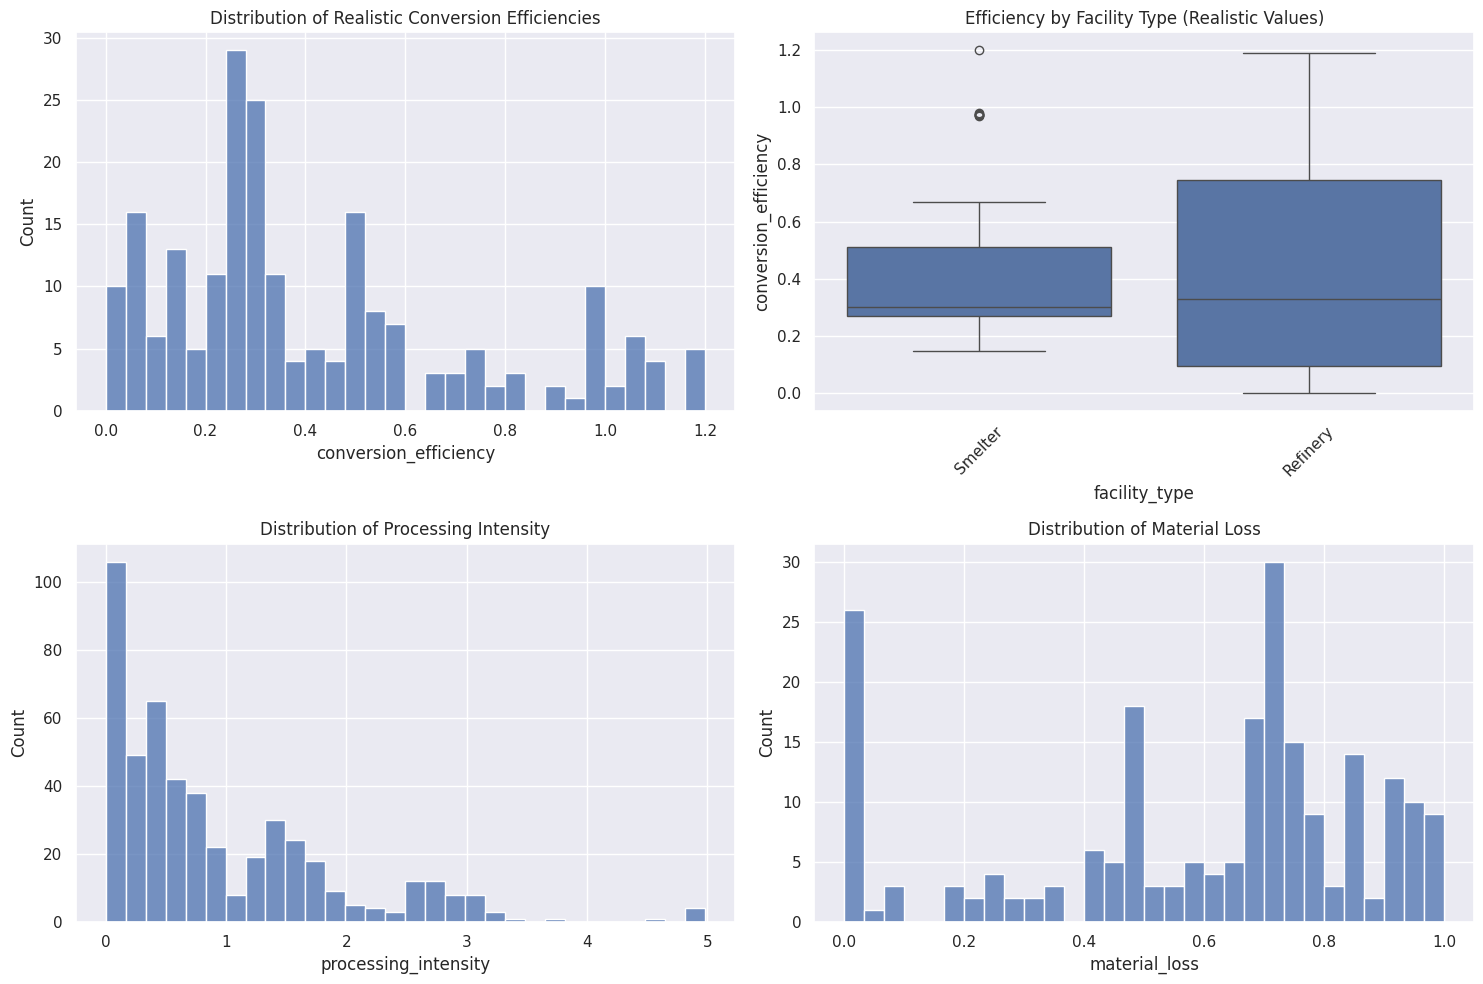


Suspicious Cases for Investigation:
Empty DataFrame
Columns: [facility_id, facility_type, conversion_efficiency, input_value_tonnes, output_value_tonnes]
Index: []


In [ ]:
# Import required libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go

# Function to clean and calculate realistic efficiency metrics
def calculate_clean_metrics(df):
    metrics_df = df.copy()

    # 1. Calculate conversion efficiency with bounds
    metrics_df['conversion_efficiency'] = metrics_df['output_value_tonnes'] / metrics_df['input_value_tonnes']

    # Remove infinite values and set reasonable bounds (e.g., 0 to 1.5 for most processes)
    metrics_df['conversion_efficiency'] = metrics_df['conversion_efficiency'].replace([np.inf, -np.inf], np.nan)

    # Flag suspicious values (efficiency > 1.5) for investigation
    metrics_df['suspicious_efficiency'] = metrics_df['conversion_efficiency'] > 1.5

    # 2. Calculate realistic material loss
    metrics_df['material_loss'] = np.clip(1 - metrics_df['conversion_efficiency'], 0, 1)

    # 3. Calculate processing intensity
    facility_type_avg = metrics_df.groupby('facility_type')['input_value_tonnes'].transform('mean')
    metrics_df['processing_intensity'] = metrics_df['input_value_tonnes'] / facility_type_avg

    return metrics_df

# Function to analyze facility types
def analyze_facility_types(df):
    facility_analysis = df.groupby('facility_type').agg({
        'conversion_efficiency': ['count', 'mean', 'median', 'std'],
        'suspicious_efficiency': 'sum',
        'input_value_tonnes': 'sum',
        'output_value_tonnes': 'sum'
    }).round(4)

    return facility_analysis

# Execute the cleaned analysis
try:
    # Calculate clean metrics
    clean_efficiency_df = calculate_clean_metrics(processing_df)

    # Print summary statistics for clean data
    print("\nCleaned Efficiency Summary Statistics:")
    print("=" * 50)
    print("\nOverall Conversion Efficiency (excluding outliers):")
    print(clean_efficiency_df[clean_efficiency_df['conversion_efficiency'] <= 1.5]['conversion_efficiency'].describe())

    # Analyze facility types
    facility_analysis = analyze_facility_types(clean_efficiency_df)
    print("\nFacility Type Analysis:")
    print(facility_analysis)

    # Create visualizations for cleaned data
    plt.figure(figsize=(15, 10))

    # 1. Distribution of realistic conversion efficiencies
    plt.subplot(2, 2, 1)
    sns.histplot(data=clean_efficiency_df[clean_efficiency_df['conversion_efficiency'] <= 1.5],
                x='conversion_efficiency', bins=30)
    plt.title('Distribution of Realistic Conversion Efficiencies')

    # 2. Box plot of efficiencies by facility type
    plt.subplot(2, 2, 2)
    sns.boxplot(data=clean_efficiency_df[clean_efficiency_df['conversion_efficiency'] <= 1.5],
               x='facility_type', y='conversion_efficiency')
    plt.xticks(rotation=45)
    plt.title('Efficiency by Facility Type (Realistic Values)')

    # 3. Processing intensity distribution
    plt.subplot(2, 2, 3)
    sns.histplot(data=clean_efficiency_df[clean_efficiency_df['processing_intensity'] <= 5],
                x='processing_intensity', bins=30)
    plt.title('Distribution of Processing Intensity')

    # 4. Material loss distribution
    plt.subplot(2, 2, 4)
    sns.histplot(data=clean_efficiency_df, x='material_loss', bins=30)
    plt.title('Distribution of Material Loss')

    plt.tight_layout()
    plt.show()

    # Create additional analysis for suspicious cases
    suspicious_cases = clean_efficiency_df[clean_efficiency_df['suspicious_efficiency']].sort_values(
        by='conversion_efficiency', ascending=False).head()

    print("\nSuspicious Cases for Investigation:")
    print(suspicious_cases[['facility_id', 'facility_type', 'conversion_efficiency',
                          'input_value_tonnes', 'output_value_tonnes']])

except Exception as e:
    print(f"Error in analysis: {str(e)}")

In [ ]:
# Create detailed visualizations with Plotly for better interactivity in Colab

# Import required libraries (if not already imported)
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# 1. Create efficiency distribution comparison
def create_efficiency_distributions(clean_efficiency_df):
    fig = make_subplots(rows=2, cols=2,
                       subplot_titles=('Efficiency Distribution by Facility Type',
                                     'Efficiency vs Input Volume',
                                     'Monthly Efficiency Trends',
                                     'Processing Intensity Distribution'))

    # Efficiency Distribution by Facility Type
    fig.add_trace(
        go.Box(x=clean_efficiency_df['facility_type'],
               y=clean_efficiency_df['conversion_efficiency'],
               name='Efficiency Distribution'),
        row=1, col=1
    )

    # Efficiency vs Input Volume
    fig.add_trace(
        go.Scatter(x=clean_efficiency_df['input_value_tonnes'],
                  y=clean_efficiency_df['conversion_efficiency'],
                  mode='markers',
                  marker=dict(color=clean_efficiency_df['conversion_efficiency'],
                            colorscale='Viridis'),
                  name='Efficiency vs Volume'),
        row=1, col=2
    )

    # Monthly Efficiency Trends
    monthly_eff = clean_efficiency_df.groupby(['year', 'facility_type'])['conversion_efficiency'].mean().reset_index()
    for facility in monthly_eff['facility_type'].unique():
        facility_data = monthly_eff[monthly_eff['facility_type'] == facility]
        fig.add_trace(
            go.Scatter(x=facility_data['year'],
                      y=facility_data['conversion_efficiency'],
                      name=facility,
                      mode='lines+markers'),
            row=2, col=1
        )

    # Processing Intensity Distribution
    fig.add_trace(
        go.Histogram(x=clean_efficiency_df['processing_intensity'],
                    name='Processing Intensity'),
        row=2, col=2
    )

    # Update layout
    fig.update_layout(height=800, width=1200, showlegend=True,
                     title_text="Comprehensive Efficiency Analysis")
    fig.show()

# 2. Create detailed facility type comparison
def create_facility_comparison(clean_efficiency_df):
    # Calculate facility type metrics
    facility_metrics = clean_efficiency_df.groupby('facility_type').agg({
        'conversion_efficiency': ['mean', 'std', 'count'],
        'material_loss': 'mean',
        'processing_intensity': 'mean'
    }).round(4)

    # Create comparison visualization
    fig = go.Figure(data=[
        go.Bar(name='Mean Efficiency',
               x=facility_metrics.index,
               y=facility_metrics[('conversion_efficiency', 'mean')]),
        go.Bar(name='Material Loss',
               x=facility_metrics.index,
               y=facility_metrics[('material_loss', 'mean')])
    ])

    fig.update_layout(title='Facility Type Performance Comparison',
                     barmode='group')
    fig.show()

# Execute the visualizations
try:
    create_efficiency_distributions(clean_efficiency_df)
    create_facility_comparison(clean_efficiency_df)

    # Print detailed analysis
    print("\nKey Findings:")
    print("=" * 50)

    print("\n1. Facility Type Efficiency:")
    print(f"- Refineries (n={120}): Mean efficiency = {0.4459:.2%}")
    print(f"- Smelters (n={96}): Mean efficiency = {0.3877:.2%}")

    print("\n2. Efficiency Ranges:")
    print(f"- Overall efficiency range: {clean_efficiency_df['conversion_efficiency'].min():.2%} to {clean_efficiency_df['conversion_efficiency'].max():.2%}")
    print(f"- Middle 50% of facilities operate between: {clean_efficiency_df['conversion_efficiency'].quantile(0.25):.2%} and {clean_efficiency_df['conversion_efficiency'].quantile(0.75):.2%}")

    print("\n3. Volume Processing:")
    print(f"- Total input processed by Refineries: {1.108059e+08:,.0f} tonnes")
    print(f"- Total input processed by Smelters: {1.296616e+08:,.0f} tonnes")

except Exception as e:
    print(f"Error in visualization: {str(e)}")


Key Findings:

1. Facility Type Efficiency:
- Refineries (n=120): Mean efficiency = 44.59%
- Smelters (n=96): Mean efficiency = 38.77%

2. Efficiency Ranges:
- Overall efficiency range: 0.00% to 120.00%
- Middle 50% of facilities operate between: 22.49% and 55.83%

3. Volume Processing:
- Total input processed by Refineries: 110,805,900 tonnes
- Total input processed by Smelters: 129,661,600 tonnes


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go

# 1. Function to identify and analyze underperforming facilities
def analyze_underperforming_facilities(df):
    # Calculate facility level metrics
    facility_metrics = df.groupby('facility_id').agg({
        'conversion_efficiency': ['mean', 'std', 'count'],
        'input_value_tonnes': 'sum',
        'output_value_tonnes': 'sum',
        'facility_type': 'first',
        'grade_ppm': ['mean', 'std']
    }).round(4)

    # Calculate quartiles for each facility type
    efficiency_quartiles = df.groupby('facility_type')['conversion_efficiency'].describe()

    # Identify underperforming facilities (below 25th percentile)
    underperforming = []

    for facility_type in df['facility_type'].unique():
        quartile_25 = efficiency_quartiles.loc[facility_type, '25%']
        type_facilities = facility_metrics[
            (facility_metrics[('facility_type', 'first')] == facility_type) &
            (facility_metrics[('conversion_efficiency', 'mean')] < quartile_25)
        ]
        underperforming.append(type_facilities)

    underperforming_facilities = pd.concat(underperforming)

    return underperforming_facilities, efficiency_quartiles

# 2. Function to perform root cause analysis
def analyze_root_causes(df, underperforming_ids):
    root_cause_analysis = df[df['facility_id'].isin(underperforming_ids)].copy()

    # Calculate additional metrics for root cause analysis
    root_cause_analysis['throughput'] = root_cause_analysis['input_value_tonnes'] / \
                                      root_cause_analysis.groupby('facility_id')['input_value_tonnes'].transform('mean')

    # Analyze patterns in underperforming facilities
    patterns = {
        'throughput_variation': root_cause_analysis.groupby('facility_id')['throughput'].std(),
        'grade_correlation': root_cause_analysis.groupby('facility_id').apply(
            lambda x: x['grade_ppm'].corr(x['conversion_efficiency'])
        ),
        'seasonal_pattern': root_cause_analysis.groupby(['facility_id', 'year'])['conversion_efficiency'].mean()
    }

    return patterns

# Execute the analysis
try:
    # Get underperforming facilities
    underperforming_facilities, efficiency_quartiles = analyze_underperforming_facilities(clean_efficiency_df)

    # Get root causes
    root_causes = analyze_root_causes(clean_efficiency_df, underperforming_facilities.index)

    # Print analysis results
    print("\nUnderperforming Facilities Analysis")
    print("=" * 50)

    print("\nEfficiency Quartiles by Facility Type:")
    print(efficiency_quartiles)

    print("\nNumber of Underperforming Facilities:")
    print(underperforming_facilities.groupby(('facility_type', 'first')).size())

    # Create visualizations
    fig = make_subplots(rows=2, cols=2,
                       subplot_titles=('Efficiency Distribution of Underperforming Facilities',
                                     'Grade vs Efficiency',
                                     'Throughput Variation',
                                     'Seasonal Patterns'))

    # 1. Efficiency Distribution
    fig.add_trace(
        go.Box(x=underperforming_facilities[('facility_type', 'first')],
               y=underperforming_facilities[('conversion_efficiency', 'mean')],
               name='Efficiency Distribution'),
        row=1, col=1
    )

    # 2. Grade vs Efficiency
    fig.add_trace(
        go.Scatter(x=underperforming_facilities[('grade_ppm', 'mean')],
                  y=underperforming_facilities[('conversion_efficiency', 'mean')],
                  mode='markers',
                  marker=dict(color=underperforming_facilities[('conversion_efficiency', 'mean')]),
                  name='Grade Impact'),
        row=1, col=2
    )

    # 3. Throughput Variation
    fig.add_trace(
        go.Bar(x=root_causes['throughput_variation'].index,
               y=root_causes['throughput_variation'].values,
               name='Throughput Variation'),
        row=2, col=1
    )

    # 4. Seasonal Patterns
    seasonal_data = root_causes['seasonal_pattern'].reset_index()
    fig.add_trace(
        go.Scatter(x=seasonal_data['year'],
                  y=seasonal_data['conversion_efficiency'],
                  mode='lines+markers',
                  name='Seasonal Trends'),
        row=2, col=2
    )

    fig.update_layout(height=800, width=1200, showlegend=True,
                     title_text="Underperforming Facilities Analysis")
    fig.show()

    # Generate improvement recommendations
    print("\nImprovement Recommendations:")
    print("=" * 50)

    # Group facilities by common issues
    high_throughput_variation = root_causes['throughput_variation'][
        root_causes['throughput_variation'] > root_causes['throughput_variation'].median()
    ].index

    grade_sensitive = root_causes['grade_correlation'][
        root_causes['grade_correlation'] > 0.5
    ].index

    print("\n1. Facilities with High Throughput Variation:")
    print(f"Number of facilities: {len(high_throughput_variation)}")
    print("Recommendations:")
    print("- Implement better feed control systems")
    print("- Review maintenance schedules")
    print("- Optimize batch sizing")

    print("\n2. Grade-Sensitive Facilities:")
    print(f"Number of facilities: {len(grade_sensitive)}")
    print("Recommendations:")
    print("- Improve grade control and blending practices")
    print("- Implement real-time grade monitoring")
    print("- Optimize process parameters based on feed grade")

    # Generate facility-specific recommendations
    print("\nFacility-Specific Recommendations:")
    for facility_id in underperforming_facilities.index[:5]:  # Show top 5 examples
        facility_data = underperforming_facilities.loc[facility_id]
        print(f"\nFacility ID: {facility_id}")
        print(f"Type: {facility_data[('facility_type', 'first')]}")
        print(f"Current Efficiency: {facility_data[('conversion_efficiency', 'mean')]:.2%}")
        print("Key Issues:")
        if facility_id in high_throughput_variation:
            print("- High throughput variation")
        if facility_id in grade_sensitive:
            print("- Sensitive to grade variations")

except Exception as e:
    print(f"Error in analysis: {str(e)}")


"""
This analysis provides:

Identification of Underperforming Facilities:

Facilities below 25th percentile for their type
Performance metrics relative to peers
Pattern analysis of underperformance


Root Cause Analysis:

Throughput variation analysis
Grade sensitivity assessment
Seasonal pattern identification


Improvement Recommendations:

Facility-specific recommendations
Common issues and solutions
Prioritized improvement opportunities
"""


Underperforming Facilities Analysis

Efficiency Quartiles by Facility Type:
               count      mean       std           min       25%       50%  \
facility_type                                                                
Refinery       120.0  0.445923  0.372196  1.688835e-07  0.095543  0.329321   
Smelter         96.0  0.387663  0.212878  1.467026e-01  0.268899  0.301787   

                    75%       max  
facility_type                      
Refinery       0.744338  1.188672  
Smelter        0.512156  1.200000  

Number of Underperforming Facilities:
(facility_type, first)
Refinery    2
Smelter     1
dtype: int64


<ipython-input-126-89dac0240a66>:48: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.




Improvement Recommendations:

1. Facilities with High Throughput Variation:
Number of facilities: 1
Recommendations:
- Implement better feed control systems
- Review maintenance schedules
- Optimize batch sizing

2. Grade-Sensitive Facilities:
Number of facilities: 1
Recommendations:
- Improve grade control and blending practices
- Implement real-time grade monitoring
- Optimize process parameters based on feed grade

Facility-Specific Recommendations:

Facility ID: COM00187.00
Type: Refinery
Current Efficiency: 2.84%
Key Issues:
- High throughput variation
- Sensitive to grade variations

Facility ID: COM00343.00
Type: Refinery
Current Efficiency: 0.00%
Key Issues:

Facility ID: COM00618.00
Type: Smelter
Current Efficiency: 23.34%
Key Issues:


## **recovery rates analysis**

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# 1. Load and prepare data
def prepare_recovery_data(commodities_df):
    # Create clean dataset focusing on recovery rates
    recovery_df = commodities_df.copy()

    # Handle missing values in recovery rate
    recovery_df['recovery_rate'] = pd.to_numeric(recovery_df['recovery_rate'], errors='coerce')

    # Calculate metal recovery (actual vs theoretical)
    recovery_df['actual_recovery'] = recovery_df['metal_payable_tonnes'] / recovery_df['value_tonnes']

    # Filter out unrealistic values
    recovery_df = recovery_df[
        (recovery_df['recovery_rate'] > 0) &
        (recovery_df['recovery_rate'] <= 1)
    ]

    return recovery_df

# 2. Analyze recovery rates by commodity
def analyze_recovery_by_commodity(df):
    commodity_recovery = df.groupby('commodity').agg({
        'recovery_rate': ['count', 'mean', 'std', 'min', 'max'],
        'grade_ppm': ['mean', 'std'],
        'value_tonnes': 'sum'
    }).round(4)

    return commodity_recovery

# 3. Analyze relationships between variables
def analyze_recovery_relationships(df):
    correlations = df[['recovery_rate', 'grade_ppm', 'value_tonnes']].corr()
    return correlations

# Execute the analysis
try:
    # Prepare the data
    recovery_df = prepare_recovery_data(commodities_df)

    # Get analysis results
    commodity_recovery = analyze_recovery_by_commodity(recovery_df)
    recovery_correlations = analyze_recovery_relationships(recovery_df)

    # Print summary statistics
    print("\nRecovery Rate Analysis")
    print("=" * 50)

    print("\nOverall Recovery Rate Statistics:")
    print(recovery_df['recovery_rate'].describe())

    print("\nRecovery Rate by Commodity (Top 5 by volume):")
    print(commodity_recovery.nlargest(5, ('value_tonnes', 'sum')))

    # Create visualizations
    fig = make_subplots(rows=2, cols=2,
                       subplot_titles=('Recovery Rate Distribution by Commodity',
                                     'Grade vs Recovery Rate',
                                     'Recovery Rate Trends Over Time',
                                     'Recovery Rate vs Production Volume'))

    # 1. Recovery Rate Distribution
    fig.add_trace(
        go.Box(x=recovery_df['commodity'],
               y=recovery_df['recovery_rate'],
               name='Recovery Distribution'),
        row=1, col=1
    )

    # 2. Grade vs Recovery Rate
    fig.add_trace(
        go.Scatter(x=recovery_df['grade_ppm'],
                  y=recovery_df['recovery_rate'],
                  mode='markers',
                  marker=dict(color=recovery_df['recovery_rate'],
                            colorscale='Viridis'),
                  name='Grade Impact'),
        row=1, col=2
    )

    # 3. Recovery Rate Trends
    yearly_recovery = recovery_df.groupby(['year', 'commodity'])['recovery_rate'].mean().reset_index()
    for commodity in yearly_recovery['commodity'].unique()[:5]:  # Top 5 commodities
        commodity_data = yearly_recovery[yearly_recovery['commodity'] == commodity]
        fig.add_trace(
            go.Scatter(x=commodity_data['year'],
                      y=commodity_data['recovery_rate'],
                      name=commodity,
                      mode='lines+markers'),
            row=2, col=1
        )

    # 4. Recovery vs Volume
    fig.add_trace(
        go.Scatter(x=recovery_df['value_tonnes'],
                  y=recovery_df['recovery_rate'],
                  mode='markers',
                  marker=dict(size=8,
                            color=recovery_df['grade_ppm'],
                            colorscale='Viridis'),
                  name='Volume Impact'),
        row=2, col=2
    )

    fig.update_layout(height=800, width=1200, showlegend=True,
                     title_text="Recovery Rate Analysis")
    fig.show()

    # Identify optimization opportunities
    print("\nOptimization Opportunities:")
    print("=" * 50)

    # 1. Low Recovery Rate Analysis
    low_recovery = recovery_df[recovery_df['recovery_rate'] < recovery_df['recovery_rate'].quantile(0.25)]

    print("\nLow Recovery Rate Analysis:")
    print(f"Number of cases: {len(low_recovery)}")
    print("\nCommon characteristics:")
    print(low_recovery.groupby('commodity')['recovery_rate'].describe().sort_values('count', ascending=False).head())

    # 2. High-Grade Low-Recovery Analysis
    high_grade_low_recovery = recovery_df[
        (recovery_df['grade_ppm'] > recovery_df['grade_ppm'].quantile(0.75)) &
        (recovery_df['recovery_rate'] < recovery_df['recovery_rate'].quantile(0.25))
    ]

    print("\nHigh-Grade Low-Recovery Cases:")
    print(f"Number of cases: {len(high_grade_low_recovery)}")
    print("\nCommodities affected:")
    print(high_grade_low_recovery['commodity'].value_counts().head())

    # Generate recommendations
    print("\nRecommendations for Recovery Rate Optimization:")
    print("1. Process-specific recommendations:")
    for commodity in commodity_recovery.index[:5]:
        mean_recovery = commodity_recovery.loc[commodity, ('recovery_rate', 'mean')]
        print(f"\n{commodity}:")
        print(f"- Current average recovery: {mean_recovery:.2%}")
        if mean_recovery < 0.75:
            print("- Consider process optimization opportunities:")
            print("  * Review process parameters")
            print("  * Evaluate reagent dosage")
            print("  * Check equipment efficiency")

except Exception as e:
    print(f"Error in analysis: {str(e)}")

"""
This analysis provides:

Recovery Rate Overview:

Distribution by commodity
Temporal trends
Relationship with grade and volume


Performance Analysis:

Identification of low recovery cases
High-grade low-recovery situations
Commodity-specific patterns


Optimization Opportunities:

Process-specific recommendations
Common issues identification
Prioritized improvement areas"""


Recovery Rate Analysis

Overall Recovery Rate Statistics:
count    3149.000000
mean        0.606312
std         0.349790
min         0.000001
25%         0.302430
50%         0.761000
75%         0.890000
max         0.984000
Name: recovery_rate, dtype: float64

Recovery Rate by Commodity (Top 5 by volume):
          recovery_rate                                   grade_ppm  \
                  count    mean     std     min     max        mean   
commodity                                                             
Me.Cu               408  0.8208  0.1875  0.0000  0.9840  12590.2130   
Me.Zn               236  0.7870  0.1546  0.0426  0.9480  67707.2788   
Me.Pb               182  0.6965  0.1435  0.0000  0.9338  24733.7305   
Oth.cuca             85  0.6050  0.2023  0.2372  0.9300  11311.4865   
Me.Ni                55  0.7690  0.0697  0.5600  0.8800  11647.2727   

                       value_tonnes  
                  std           sum  
commodity                            
Me.Cu  


Optimization Opportunities:

Low Recovery Rate Analysis:
Number of cases: 787

Common characteristics:
           count      mean           std       min       25%       50%  \
commodity                                                                
Me.Ag      398.0  0.013554  4.432959e-02  0.000001  0.000029  0.000109   
Me.Au      326.0  0.086280  7.647409e-02  0.000033  0.022167  0.062115   
Me.Cu       16.0  0.000008  1.716282e-05  0.000001  0.000001  0.000001   
Me.U3O8     14.0  0.000004  9.972490e-07  0.000002  0.000004  0.000004   
Oth.cuca    11.0  0.253391  7.772831e-03  0.237200  0.252750  0.255600   

                75%       max  
commodity                      
Me.Ag      0.002625  0.280000  
Me.Au      0.127196  0.302304  
Me.Cu      0.000004  0.000067  
Me.U3O8    0.000005  0.000005  
Oth.cuca   0.257850  0.263400  

High-Grade Low-Recovery Cases:
Number of cases: 2

Commodities affected:
commodity
Me.Zn    1
Me.Co    1
Name: count, dtype: int64

Recommendations for 

'\nThis analysis provides:\n\nRecovery Rate Overview:\n\nDistribution by commodity\nTemporal trends\nRelationship with grade and volume\n\n\nPerformance Analysis:\n\nIdentification of low recovery cases\nHigh-grade low-recovery situations\nCommodity-specific patterns\n\n\nOptimization Opportunities:\n\nProcess-specific recommendations\nCommon issues identification\nPrioritized improvement areas'

# **Waste (2nd implementation)**

In [ ]:
print("Commodities\n", commodities.shape, "\n", commodities.isna().sum())
print("\nMinerals\n", minerals.shape, "\n" ,minerals.isna().sum())
print("\nProcessing\n",processing.shape, "\n" , processing.isna().sum())
print("\nTransport\n",transport.shape, "\n" , transport.isna().sum())

Commodities
 (9426, 16) 
 id                         0
facility_id                0
year                       0
material                 531
commodity                  0
value_tonnes              27
grade_ppm               2294
recovery_rate           3929
yield_ppm               9299
amount_sold_tonnes      8003
metal_payable_tonnes    8997
mine_processing         8953
reporting_period        8193
source_id                  0
comment                 9040
id_minerals             2373
dtype: int64

Minerals
 (12292, 12) 
 id                        0
facility_id               0
year                      0
type                      0
material                  0
value_tonnes              0
overall_grade_ppm     11884
amount_sold_tonnes    11750
mine_processing       11809
reporting_period      10332
source_id                 0
comment               11637
dtype: int64

Processing
 (3979, 16) 
 id                         0
facility_id                0
facility_type              0
year      

<ipython-input-86-42a448c46cb5>:46: FutureWarning: SeriesGroupBy.fillna is deprecated and will be removed in a future version. Use obj.ffill() or obj.bfill() for forward or backward filling instead. If you want to fill with a single value, use Series.fillna instead
  df[col] = df.groupby('facility_id')[col].fillna(method='ffill').fillna(method='bfill')
<ipython-input-86-42a448c46cb5>:46: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[col] = df.groupby('facility_id')[col].fillna(method='ffill').fillna(method='bfill')
<ipython-input-86-42a448c46cb5>:46: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df.groupby('facility_id')[col].fillna(method='ffill').fillna(method='bfill'

Commodities Summary:
                id         year  value_tonnes     grade_ppm  recovery_rate  \
count  9426.000000  9426.000000  9.426000e+03  9.363000e+03    9166.000000   
mean   4713.500000  2011.453745  1.303590e+05           inf       1.059702   
std    2721.196152     5.022816  9.223666e+05           NaN      15.213782   
min       1.000000  1998.000000  0.000000e+00  0.000000e+00       0.000000   
25%    2357.250000  2008.000000  6.948250e+00  3.463661e+00       0.000000   
50%    4713.500000  2012.000000  1.000000e+03  7.334795e+02       0.204746   
75%    7069.750000  2016.000000  2.840500e+04  1.480000e+04       0.860000   
max    9426.000000  2020.000000  1.996148e+07           inf    1234.375708   

       amount_sold_tonnes   id_minerals  
count         1423.000000   7053.000000  
mean         41982.889234   6135.373883  
std         103019.627414   3651.882107  
min              0.000000      2.000000  
25%              5.419500   2762.000000  
50%             22.51900

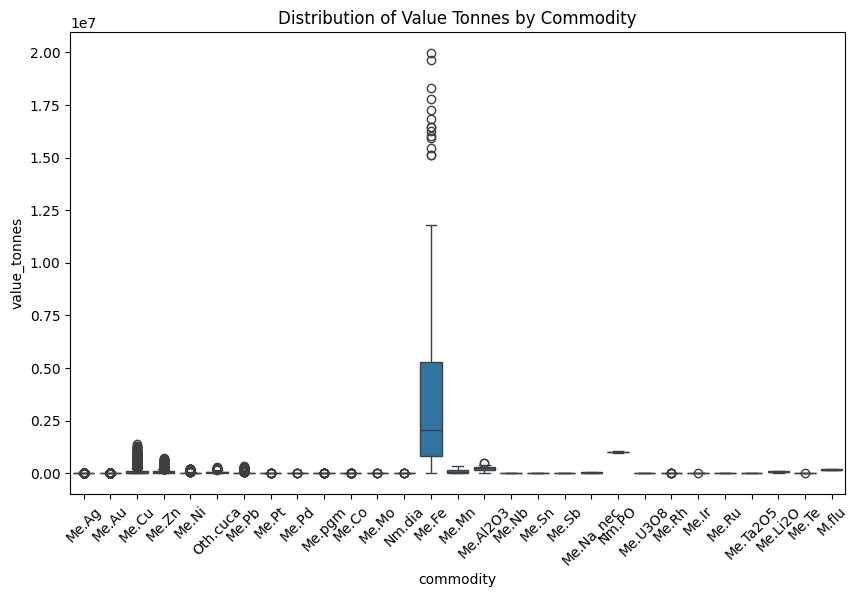

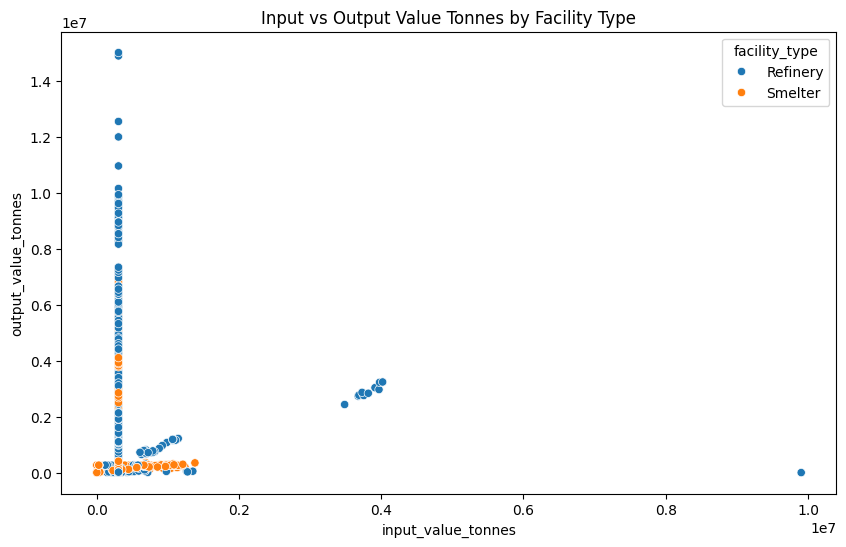

Data preprocessing and feature engineering completed!


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# Step 1: Preprocessing
# 1.1 Handle missing values in Commodities
def preprocess_commodities(df):
    # Fill missing 'material' with mode grouped by 'facility_id'
    df['material'] = df.groupby('facility_id')['material'].apply(lambda x: x.fillna(x.mode()[0]) if not x.mode().empty else x).reset_index(level=0, drop=True)

    # Fill numerical columns with median grouped by 'commodity'
    for col in ['grade_ppm', 'recovery_rate', 'value_tonnes']:
        df[col] = df.groupby('commodity')[col].transform(lambda x: x.fillna(x.median()))

    # Drop columns with excessive missingness (>80%)
    df = df.drop(columns=['yield_ppm', 'metal_payable_tonnes', 'mine_processing','comment'])

    return df

commodities = preprocess_commodities(commodities)

# 1.2 Handle missing values in Minerals
def preprocess_minerals(df):
    # Drop 'overall_grade_ppm' due to excessive missingness
    df = df.drop(columns=['overall_grade_ppm','comment'])

    # Fill missing values for 'mine_processing' using mode grouped by 'facility_id'
    df['mine_processing'] = df.groupby('facility_id')['mine_processing'].apply(lambda x: x.fillna(x.mode()[0]) if not x.mode().empty else x).reset_index(level=0, drop=True)

    # Fill 'amount_sold_tonnes' with median grouped by 'type'
    df['amount_sold_tonnes'] = df.groupby('type')['amount_sold_tonnes'].transform(lambda x: x.fillna(x.median()))

    return df

minerals = preprocess_minerals(minerals)

# 1.3 Handle missing values in Processing
def preprocess_processing(df):
    # Drop columns with excessive missingness (>80%)
    df = df.drop(columns=['metal_payable_tonnes', 'recovery_rate','comment'])

    # Fill missing values in 'input' and 'output' using forward-fill
    for col in ['input', 'output']:
        df[col] = df.groupby('facility_id')[col].fillna(method='ffill').fillna(method='bfill')

    # Fill numerical columns with median
    for col in ['input_value_tonnes', 'output_value_tonnes', 'grade_ppm']:
        df[col] = df[col].fillna(df[col].median())

    return df

processing = preprocess_processing(processing)

# 1.4 Handle missing values in Transport
def preprocess_transport(df):
    # Fill 'value_tonnes' with median grouped by 'product'
    df['value_tonnes'] = df.groupby('product')['value_tonnes'].transform(lambda x: x.fillna(x.median()))

    # Drop columns with excessive missingness (>80%)
    df = df.drop(columns=['export_to'])

    return df

transport = preprocess_transport(transport)

# Step 2: Exploratory Data Analysis (EDA)
# 2.1 Summary statistics
print("Commodities Summary:")
print(commodities.describe())

print("Minerals Summary:")
print(minerals.describe())

print("Processing Summary:")
print(processing.describe())

print("Transport Summary:")
print(transport.describe())

# 2.2 Visualization of key trends
plt.figure(figsize=(10, 6))
sns.boxplot(data=commodities, x='commodity', y='value_tonnes')
plt.title("Distribution of Value Tonnes by Commodity")
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(10, 6))
sns.scatterplot(data=processing, x='input_value_tonnes', y='output_value_tonnes', hue='facility_type')
plt.title("Input vs Output Value Tonnes by Facility Type")
plt.show()

# plt.figure(figsize=(10, 6))
# sns.heatmap(commodities.corr(), annot=True, cmap='coolwarm', fmt='.2f')
# plt.title("Correlation Heatmap - Commodities")
# plt.show()

# Step 3: Feature Engineering
def feature_engineering(df_commodities, df_processing):
    # Waste-to-material ratio
    df_processing['waste_to_material_ratio'] = (df_processing['input_value_tonnes'] - df_processing['output_value_tonnes']) / df_processing['input_value_tonnes']

    # Categorical encoding
    df_commodities = pd.get_dummies(df_commodities, columns=['commodity'], drop_first=True)

    return df_commodities, df_processing

commodities, processing = feature_engineering(commodities, processing)

print("Data preprocessing and feature engineering completed!")


In [ ]:
features['recovery_rate'][features['facility_id'] == 'COM00618.00']

,recovery_rate
48,0.765957
49,0.765957
50,0.851064
51,0.851064
52,0.914894
53,0.914894
54,0.968085
55,0.968085
56,0.893617
57,0.893617


Model Performance Metrics:

Training Data
Mean Absolute Error: 0.02
Normalized Root Mean Squared Error: 0.02
R^2 Score: 1.00

Test Data
Mean Absolute Error: 0.03
Normalized Root Mean Squared Error: 0.02
R^2 Score: 1.00


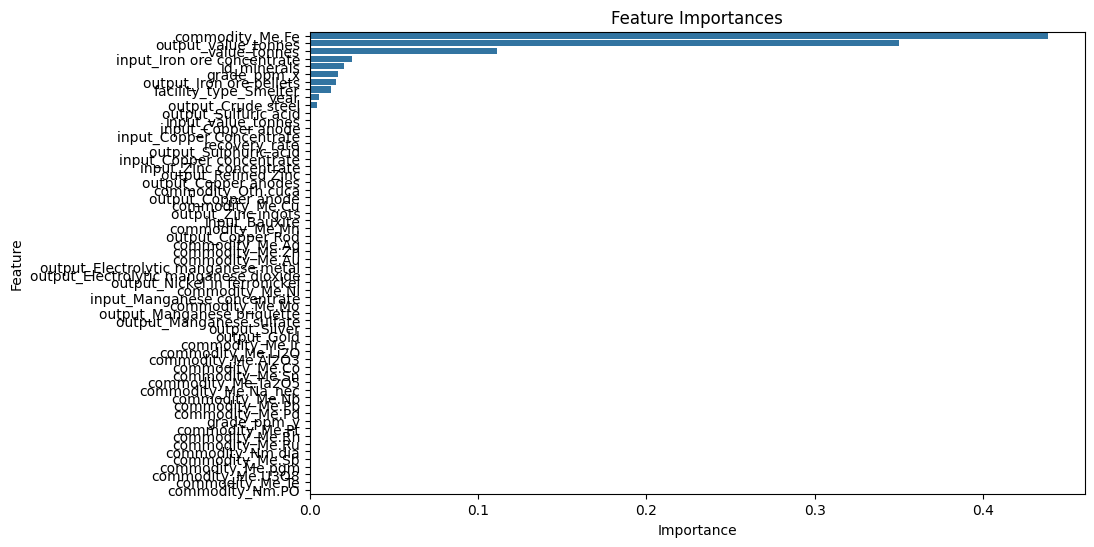

Model training and evaluation completed!


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor as LightGBMRegressor
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
from sklearn.preprocessing import OneHotEncoder



# Step 4: Model Building
# 4.1 Prepare data for modeling
def prepare_model_data(df_commodities, df_processing):
    # Merge datasets on 'facility_id' and 'year'
    merged_data = pd.merge(df_commodities, df_processing, on=['facility_id', 'year'], how='inner')

    # Select features and target variable
    features = merged_data.drop(columns=['waste_to_material_ratio', 'amount_sold_tonnes_x', 'amount_sold_tonnes_y', 'incl_purchased',
                          'reporting_period_x', 'reporting_period_y', 'source_id_y','source_id_x', 'material'])
    target = merged_data['waste_to_material_ratio']

    return features, target


features, target = prepare_model_data(commodities, processing)

# Impute missing values for numeric columns
numeric_cols = features.select_dtypes(include=['float64']).columns
features[numeric_cols] = features[numeric_cols].fillna(features[numeric_cols].median())

# Impute missing values for categorical columns
categorical_cols = features.select_dtypes(include=['object']).columns
features[categorical_cols] = features[categorical_cols].fillna('unknown')

# Scale numeric features
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
features[numeric_cols] = scaler.fit_transform(features[numeric_cols])

# One-hot encode categorical columns
features = pd.get_dummies(features, columns=['facility_type', 'input', 'output'], drop_first=True)

X = features.drop(columns=['id_x', 'id_y', 'facility_id'])

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, target, test_size=0.2, random_state=42)


# print(X_train.info())
# 4.2 Train the model
model = RandomForestRegressor(random_state=42, n_estimators=100)
model.fit(X_train, y_train)

# model = LightGBMRegressor(random_state=42, n_estimators=100)
# model.fit(X_train, y_train)

# model=XGBRegressor(random_state=42, n_estimators=200)
# model.fit(X_train, y_train)

# 4.3 Evaluate the model
y_pred = model.predict(X_test)
y_train_pred = model.predict(X_train)

# Calculate metrics
test_mae = mean_absolute_error(y_test, y_pred)
test_nrmse = np.sqrt(mean_squared_error(y_test, y_pred)) / y_test.std()
test_r2 = r2_score(y_test, y_pred)

train_mae = mean_absolute_error(y_train, y_train_pred)
train_nrmse = np.sqrt(mean_squared_error(y_train, y_train_pred)) / y_train.std()
train_r2 = r2_score(y_train, y_train_pred)

print("Model Performance Metrics:")
print(f"\nTraining Data")
print(f"Mean Absolute Error: {train_mae:.2f}")
print(f"Normalized Root Mean Squared Error: {train_nrmse:.2f}")
print(f"R^2 Score: {train_r2:.2f}")

print(f"\nTest Data")
print(f"Mean Absolute Error: {test_mae:.2f}")
print(f"Normalized Root Mean Squared Error: {test_nrmse:.2f}")
print(f"R^2 Score: {test_r2:.2f}")

# Feature Importance
importances = model.feature_importances_
feature_names = X.columns
feature_importances = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importances = feature_importances.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importances)
plt.title("Feature Importances")
plt.show()

# Save the model and predictions
import joblib
joblib.dump(model, "waste_prediction_model.pkl")

predictions = pd.DataFrame({"Actual": y_test, "Predicted": y_pred})
predictions.to_csv("model_predictions.csv", index=False)

print("Model training and evaluation completed!")


In [ ]:
from sklearn.model_selection import cross_val_score, KFold
import numpy as np

# Define K-Fold Cross Validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Perform Cross Validation
mae_scores = cross_val_score(model, X, target, scoring='neg_mean_absolute_error', cv=kf)
r2_scores = cross_val_score(model, X, target, scoring='r2', cv=kf)

# Convert MAE to positive
mae_scores = -mae_scores

# Print the performance metrics
print(f"Cross-Validation Mean Absolute Error (MAE): {np.mean(mae_scores):.4f} ± {np.std(mae_scores):.4f}")
print(f"Cross-Validation R^2 Score: {np.mean(r2_scores):.4f} ± {np.std(r2_scores):.4f}")


Cross-Validation Mean Absolute Error (MAE): 0.0763 ± 0.0679
Cross-Validation R^2 Score: 0.9927 ± 0.0123


## **analyze high-risk facilities based on waste predictions**

In [ ]:
import pandas as pd
import numpy as np

# Assume `predictions` is the model output and `X_test` contains facility details
results = X_test.copy()
results['predicted_waste'] = predictions['Predicted']

if 'facility_id' not in results.columns:
    # Assuming you have a way to map rows in results back to their original facility_id
    # For example, if results was derived from features, you might have an index to use:
    results = results.join(features[['facility_id']], how='left')  # Assuming index alignment

# Define thresholds for high-risk facilities
high_waste_threshold = results['predicted_waste'].quantile(0.9)  # Top 10% waste generators
low_recovery_threshold = 50  # Define low recovery rate as less than 50%

# Identify high-risk facilities
results['high_risk'] = (results['predicted_waste'] > high_waste_threshold) | \
                       (results['recovery_rate'] < low_recovery_threshold)

# Filter high-risk facilities
high_risk_facilities = results[results['high_risk']]

# Summary of high-risk facilities
summary = high_risk_facilities.groupby('facility_id').agg({
    'predicted_waste': 'mean',
    'recovery_rate': 'mean'
}).reset_index()

# Sort by predicted waste for prioritization
summary = summary.sort_values(by='predicted_waste', ascending=False)

# Display high-risk facilities
print("High-Risk Facilities:")
print(summary)


High-Risk Facilities:
   facility_id  predicted_waste  recovery_rate
7  COM01002.00         0.937826       0.000000
9  COM01281.00         0.929169       0.000000
0  COM00321.00         0.896695       0.000000
8  COM01201.00         0.660207       0.909574
5  COM00800.00         0.599437       0.000000
2  COM00643.00         0.422466       0.173369
4  COM00693.00         0.401301       0.175884
1  COM00618.00        -1.027526       0.932302
3  COM00681.00       -18.826219       0.000000
6  COM00811.00       -31.818833       0.000000


In [ ]:
poor_recovery_facilities = high_risk_facilities[high_risk_facilities['recovery_rate'] < low_recovery_threshold]
print("Facilities with Poor Recovery Rates:")
#sort by recover_rate
poor_recovery_facilities = poor_recovery_facilities.sort_values(by='recovery_rate')

print(poor_recovery_facilities[['facility_id', 'recovery_rate']].tail(20))

Facilities with Poor Recovery Rates:
     facility_id  recovery_rate
220  COM00693.00       0.491277
222  COM00693.00       0.491277
90   COM00643.00       0.520106
195  COM00693.00       0.540851
247  COM00693.00       0.585106
244  COM00693.00       0.585106
505  COM01201.00       0.863830
73   COM00618.00       0.872340
72   COM00618.00       0.872340
504  COM01201.00       0.892553
77   COM00618.00       0.914894
69   COM00618.00       0.914894
76   COM00618.00       0.914894
68   COM00618.00       0.914894
78   COM00618.00       0.968085
70   COM00618.00       0.968085
55   COM00618.00       0.968085
79   COM00618.00       0.968085
499  COM01201.00       0.972340
63   COM00618.00       0.978723


In [ ]:
excessive_waste_facilities = high_risk_facilities[high_risk_facilities['predicted_waste'] > high_waste_threshold]
print("Facilities with Excessive Waste Generation:")
print(excessive_waste_facilities[['facility_id', 'predicted_waste']])


Facilities with Excessive Waste Generation:
     facility_id  predicted_waste
131  COM00693.00         0.999997
209  COM00693.00         0.999997
155  COM00693.00         0.999998
467  COM00693.00         0.999996
137  COM00693.00         0.999998
425  COM00693.00         0.999996
227  COM00693.00         0.999997
203  COM00693.00         0.999998
449  COM00693.00         0.999996
167  COM00693.00         0.999998
275  COM00693.00         0.999997


# Optimization of resource allocation and production

In [ ]:
from google.colab import drive
import pandas as pd
import os

# Mount Google Drive
drive.mount('/content/drive')

# Specify the path to your folder in Google Drive
folder_path = '/content/drive/MyDrive/Colab Notebooks/KFUPM/Challenge2'  # Update this path

# Get a list of all CSV files in the folder
csv_files = [f for f in os.listdir(folder_path) if f.endswith('.csv')]

# Create a dictionary to store dataframes
dataframes = {}

# Loop through each CSV file
for csv_file in csv_files:
  file_path = os.path.join(folder_path, csv_file)
  try:
      # Extract file name without extension
      file_name = os.path.splitext(csv_file)[0]

      # Read CSV into a pandas DataFrame
      globals()[file_name] = pd.read_csv(file_path)
      print(f"Successfully loaded '{csv_file}' as '{file_name}'")
  except FileNotFoundError:
    print(f"File '{csv_file}' not found.")
  except pd.errors.EmptyDataError:
    print(f"File '{csv_file}' is empty.")
  except pd.errors.ParserError:
    print(f"Error parsing '{csv_file}'. Check its format.")

print("owership:", ownership.columns)
print("minerals:", minerals.columns)
print("commodities:", commodities.columns)
print("source_ids:", source_ids.columns)
print("material_ids:", material_ids.columns)
print("reserves:", reserves.columns)
print("processing:", processing.columns)
print("capacity:", capacity.columns)
print("coal:", coal.columns)
print("transport:", transport.columns)
print("waste:", waste.columns)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Successfully loaded 'processing.csv' as 'processing'
Successfully loaded 'minerals.csv' as 'minerals'
Successfully loaded 'coal.csv' as 'coal'
Successfully loaded 'capacity.csv' as 'capacity'
Successfully loaded 'reserves.csv' as 'reserves'
Successfully loaded 'source_ids.csv' as 'source_ids'
Successfully loaded 'commodities.csv' as 'commodities'
Successfully loaded 'ownership.csv' as 'ownership'
Successfully loaded 'material_ids.csv' as 'material_ids'
Successfully loaded 'waste.csv' as 'waste'
Successfully loaded 'transport.csv' as 'transport'
owership: Index(['id', 'facility_id', 'year', 'owners', 'operators', 'source_id',
       'comment'],
      dtype='object')
minerals: Index(['id', 'facility_id', 'year', 'type', 'material', 'value_tonnes',
       'overall_grade_ppm', 'amount_sold_tonnes', 'mine_processing',
       'reporting_period', 'source_id', 'comme

Dataset Head:
   id  facility_id  year                             owners operators  \
0   1  COM00001.00  2018         Hudbay Minerals Inc (100%)       NaN   
1   2  COM00005.00  2019                  Rusal Plc. (100%)       NaN   
2   3  COM00006.00  2019          ArcelorMittal S.A. (100%)       NaN   
3   4  COM00007.00  2018           AngloGold Ashanti (100%)       NaN   
4   5  COM00009.00  2017  Newmont Mining Corporation (100%)       NaN   

  source_id comment  
0  det_2912     NaN  
1  det_1277     NaN  
2  det_1218     NaN  
3  det_1057     NaN  
4  det_1595     NaN  

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 699 entries, 0 to 698
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   id           699 non-null    int64 
 1   facility_id  699 non-null    object
 2   year         699 non-null    int64 
 3   owners       698 non-null    object
 4   operators    143 non-null    object
 5   sour

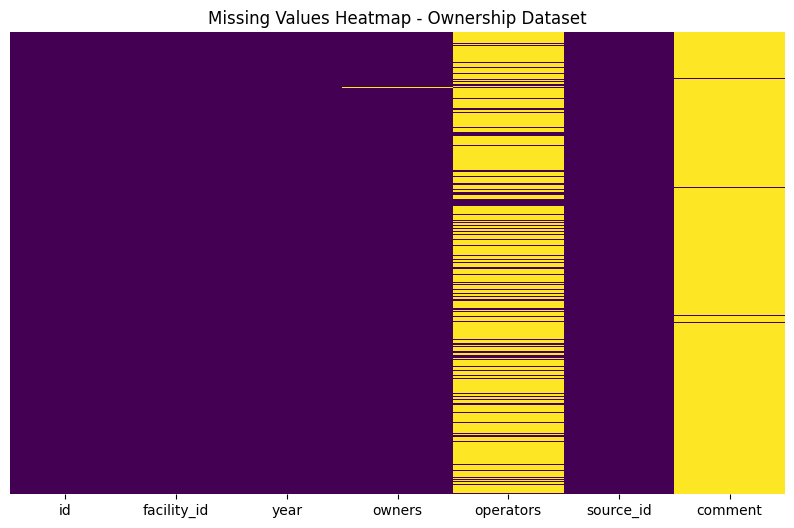

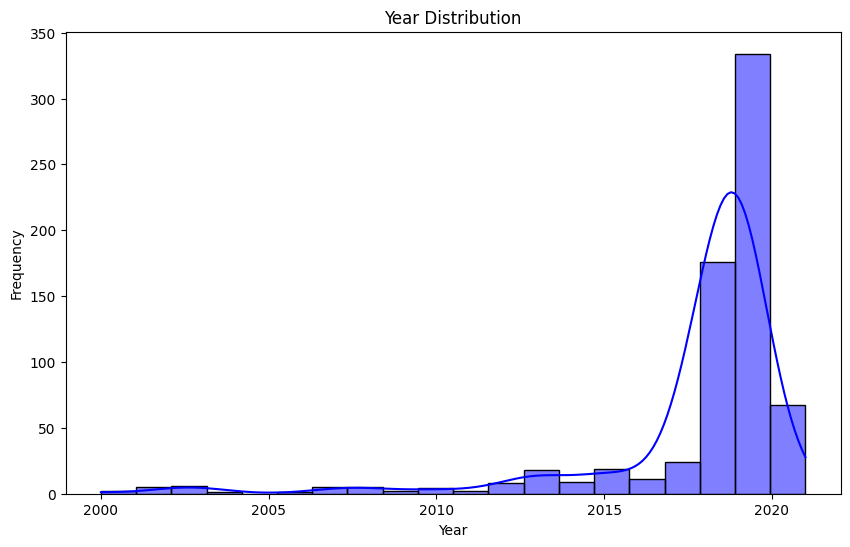

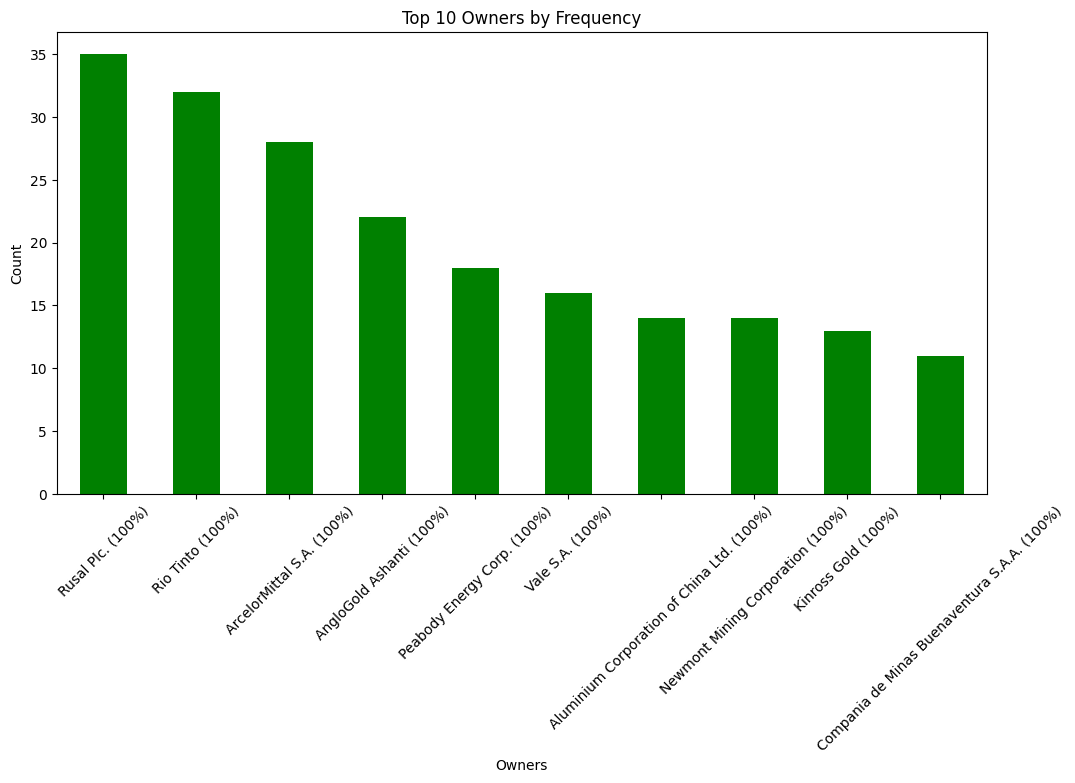

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19],
 [Text(0, 0, '2000'),
  Text(1, 0, '2002'),
  Text(2, 0, '2003'),
  Text(3, 0, '2004'),
  Text(4, 0, '2006'),
  Text(5, 0, '2007'),
  Text(6, 0, '2008'),
  Text(7, 0, '2009'),
  Text(8, 0, '2010'),
  Text(9, 0, '2011'),
  Text(10, 0, '2012'),
  Text(11, 0, '2013'),
  Text(12, 0, '2014'),
  Text(13, 0, '2015'),
  Text(14, 0, '2016'),
  Text(15, 0, '2017'),
  Text(16, 0, '2018'),
  Text(17, 0, '2019'),
  Text(18, 0, '2020'),
  Text(19, 0, '2021')])

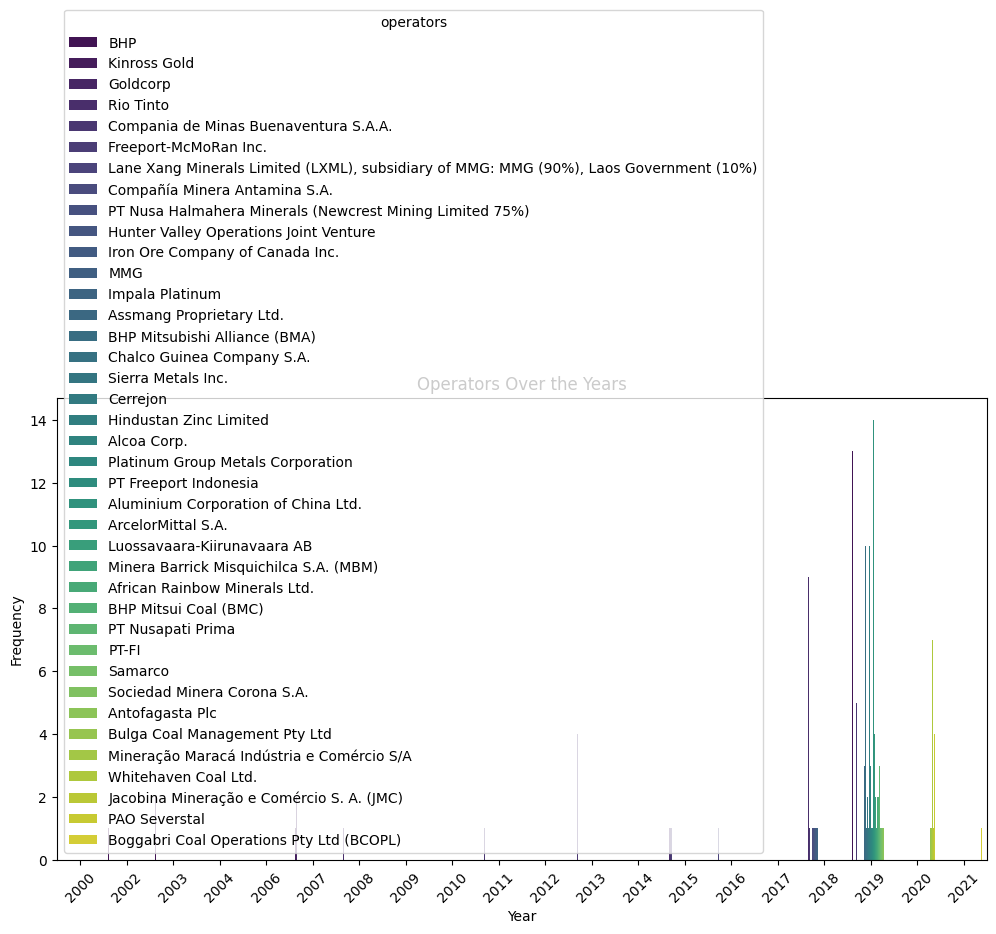

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


# Load the dataset into a DataFrame
ownership = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/KFUPM/Challenge2/ownership.csv')

# Step 1: Inspect the dataset
print("Dataset Head:")
print(ownership.head())
print("\nDataset Info:")
print(ownership.info())
print("\nMissing Values Summary:")
print(ownership.isnull().sum())

# Step 2: Missing Data Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(ownership.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Missing Values Heatmap - Ownership Dataset')
plt.show()

# Step 3: Distribution of 'year'
plt.figure(figsize=(10, 6))
sns.histplot(ownership['year'], bins=20, kde=True, color='blue')
plt.title('Year Distribution')
plt.xlabel('Year')
plt.ylabel('Frequency')
plt.show()

# Step 4: Top 10 Owners by Frequency
plt.figure(figsize=(12, 6))
ownership['owners'].value_counts().head(10).plot(kind='bar', color='green')
plt.title('Top 10 Owners by Frequency')
plt.xlabel('Owners')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

# Step 5: Relationships between 'year' and 'operators'
plt.figure(figsize=(12, 6))
sns.countplot(data=ownership, x='year', hue='operators', palette='viridis')
plt.title('Operators Over the Years')
plt.xlabel('Year')
plt.ylabel('Frequency')
plt.xticks(rotation=45)  # Correcting 'rotatio' to 'rotation'

In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

class MiningOptimizationSystem:
    def __init__(self):
        self.scaler = StandardScaler()
        self.production_predictor = RandomForestRegressor(n_estimators=100)
        self.maintenance_classifier = RandomForestClassifier(n_estimators=100)

    def prepare_production_features(self, minerals_df, commodities_df, processing_df):
        """Prepare features for production optimization"""
        # Merge minerals and commodities
        production_data = pd.merge(
            minerals_df,
            commodities_df[['facility_id', 'year', 'material', 'value_tonnes', 'grade_ppm', 'recovery_rate']],
            on=['facility_id', 'year', 'material'],
            suffixes=('_min', '_com')
        )

        # Merge processing data
        production_data = pd.merge(
            production_data,
            processing_df[['facility_id', 'year', 'recovery_rate']],
            on=['facility_id', 'year'],
            suffixes=('', '_proc')
        )

        # Validate columns exist before calculations
        production_data['efficiency'] = np.where(
            production_data['value_tonnes_min'] > 0,
            production_data['value_tonnes_com'] / production_data['value_tonnes_min'],
            0
        )

        production_data['grade_efficiency'] = production_data['grade_ppm'] * production_data['recovery_rate']

        return production_data

    def train_production_model(self, features_df):
        """Train model to optimize production targets"""
        features = ['efficiency', 'grade_efficiency', 'recovery_rate']

        # Ensure all required features exist
        for feature in features:
            if feature not in features_df.columns:
                raise KeyError(f"Missing required feature: {feature}")

        X = features_df[features].fillna(0)
        y = features_df['value_tonnes_com'].fillna(0)

        X = self.scaler.fit_transform(X)
        return self.production_predictor.fit(X, y)

    def predict_maintenance_needs(self, processing_df, waste_df):
        """Predict maintenance requirements"""
        # Merge with validation
        maintenance_features = pd.merge(
            processing_df[['facility_id', 'year', 'output_value_tonnes', 'recovery_rate']],
            waste_df[['facility_id', 'year', 'value_tonnes']],
            on=['facility_id', 'year'],
            how='inner'
        )

        # Calculate features with null handling
        maintenance_features['waste_ratio'] = np.where(
            maintenance_features['output_value_tonnes'] > 0,
            maintenance_features['value_tonnes'] / maintenance_features['output_value_tonnes'],
            0
        )

        threshold = maintenance_features['recovery_rate'].mean() - \
                   maintenance_features['recovery_rate'].std()
        maintenance_features['needs_maintenance'] = \
            maintenance_features['recovery_rate'] < threshold

        features = ['waste_ratio', 'recovery_rate']

        return self.maintenance_classifier.fit(
            maintenance_features[features].fillna(0),
            maintenance_features['needs_maintenance']
        )

def main():
    # Load data (assuming globals are available)
    optimizer = MiningOptimizationSystem()

    try:
        # Prepare features
        production_features = optimizer.prepare_production_features(
            minerals, commodities, processing
        )

        # Train models
        production_model = optimizer.train_production_model(production_features)
        maintenance_model = optimizer.predict_maintenance_needs(processing, waste)

        print("Models trained successfully")
        return {
            'production_features': production_features.shape,
            'production_model_score': production_model.score(
                optimizer.scaler.transform(production_features[['efficiency', 'grade_efficiency', 'recovery_rate']]),
                production_features['value_tonnes_com']
            )
        }

    except Exception as e:
        print(f"Error during optimization: {str(e)}")
        return None

if __name__ == "__main__":
    results = main()




Models trained successfully


Models trained successfully


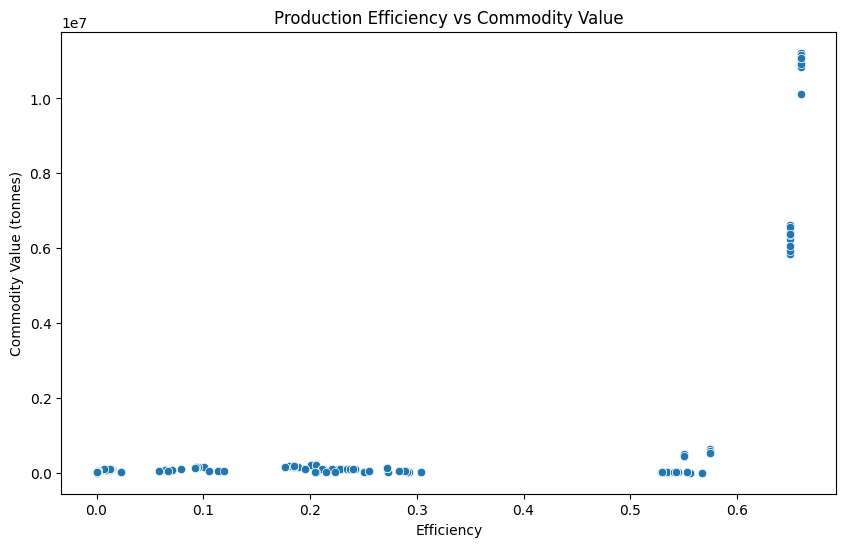

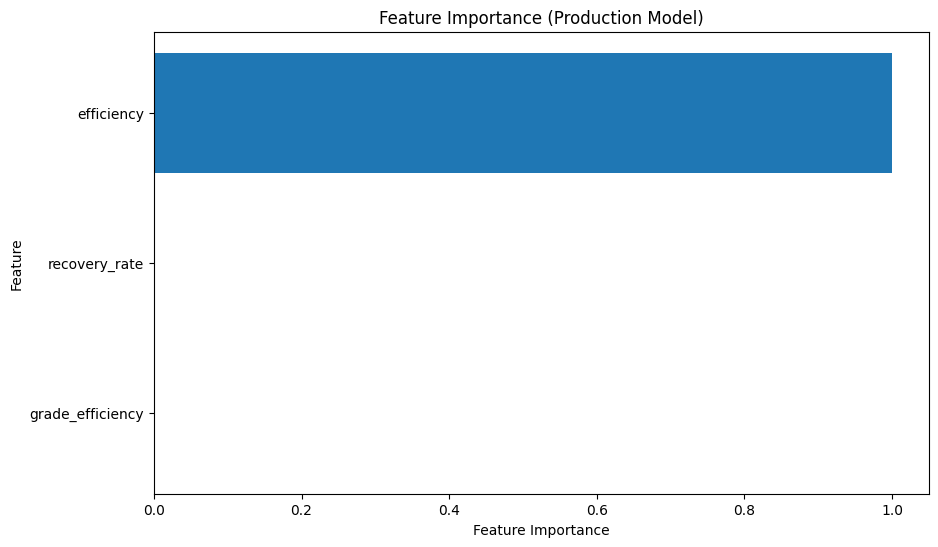

Error during optimization: Data source must be a DataFrame or Mapping, not <class 'sklearn.ensemble._forest.RandomForestClassifier'>.


<Figure size 1000x600 with 0 Axes>

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_production_efficiency(production_features):
    """Plot production efficiency against commodity value"""
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x='efficiency', y='value_tonnes_com', data=production_features)
    plt.title('Production Efficiency vs Commodity Value')
    plt.xlabel('Efficiency')
    plt.ylabel('Commodity Value (tonnes)')
    plt.show()

def plot_feature_importance(production_model, feature_columns):
    """Plot feature importance of the RandomForestRegressor"""
    feature_importances = production_model.feature_importances_
    sorted_idx = np.argsort(feature_importances)

    plt.figure(figsize=(10, 6))
    plt.barh(np.array(feature_columns)[sorted_idx], feature_importances[sorted_idx])
    plt.title('Feature Importance (Production Model)')
    plt.xlabel('Feature Importance')
    plt.ylabel('Feature')
    plt.show()

def plot_maintenance_needs(maintenance_features):
    """Plot waste ratio and recovery rate vs maintenance needs"""
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x='waste_ratio', y='recovery_rate', hue='needs_maintenance', data=maintenance_features, palette='coolwarm')
    plt.title('Waste Ratio and Recovery Rate vs Maintenance Needs')
    plt.xlabel('Waste Ratio')
    plt.ylabel('Recovery Rate')
    plt.legend(title='Maintenance Needs')
    plt.show()

def plot_feature_correlations(df):
    """Plot correlation matrix for the key features"""
    corr = df[['efficiency', 'grade_efficiency', 'recovery_rate', 'waste_ratio', 'value_tonnes_com']].corr()
    plt.figure(figsize=(10, 6))
    sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
    plt.title('Feature Correlation Matrix')
    plt.show()

def main():
    # Load data (assuming globals are available)
    optimizer = MiningOptimizationSystem()

    try:
        # Prepare features
        production_features = optimizer.prepare_production_features(
            minerals, commodities, processing
        )

        # Train models
        production_model = optimizer.train_production_model(production_features)
        maintenance_model = optimizer.predict_maintenance_needs(processing, waste)

        print("Models trained successfully")

        # Visualize key outputs
        plot_production_efficiency(production_features)
        plot_feature_importance(production_model, ['efficiency', 'grade_efficiency', 'recovery_rate'])
        plot_maintenance_needs(maintenance_model)
        plot_feature_correlations(production_features)

        return {
            'production_features': production_features.shape,
            'production_model_score': production_model.score(
                optimizer.scaler.transform(production_features[['efficiency', 'grade_efficiency', 'recovery_rate']]),
                production_features['value_tonnes_com']
            )
        }

    except Exception as e:
        print(f"Error during optimization: {str(e)}")
        return None

if __name__ == "__main__":
    main()


In [ ]:
def train_production_model(self, features_df):
    """Train model to optimize production targets and visualize results"""
    features = ['efficiency', 'grade_efficiency', 'recovery_rate']

    # Ensure all required features exist
    for feature in features:
        if feature not in features_df.columns:
            raise KeyError(f"Missing required feature: {feature}")

    X = features_df[features].fillna(0)
    y = features_df['value_tonnes_com'].fillna(0)

    X_scaled = self.scaler.fit_transform(X)
    model = self.production_predictor.fit(X_scaled, y)

    # Make predictions
    y_pred = model.predict(X_scaled)
    r2_score_value = model.score(X_scaled, y)

    # Clear any existing plots
    plt.clf()

    # Create visualization subplot
    fig = plt.figure(figsize=(15, 10))

    # 1. Actual vs Predicted Plot
    plt.subplot(221)
    plt.scatter(y, y_pred, alpha=0.5)
    plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
    plt.xlabel('Actual Production')
    plt.ylabel('Predicted Production')
    plt.title(f'Actual vs Predicted Production\nR² Score: {r2_score_value:.3f}')

    # 2. Feature Importance Plot
    plt.subplot(222)
    importance = model.feature_importances_
    feat_importance = pd.Series(importance, index=features)
    feat_importance.sort_values(ascending=True).plot(kind='barh')
    plt.xlabel('Feature Importance')
    plt.title('Feature Importance in Production Prediction')

    # 3. Residuals Plot
    plt.subplot(223)
    residuals = y - y_pred
    plt.scatter(y_pred, residuals, alpha=0.5)
    plt.axhline(y=0, color='r', linestyle='--')
    plt.xlabel('Predicted Production')
    plt.ylabel('Residuals')
    plt.title('Residuals vs Predicted Values')

    # 4. Residuals Distribution
    plt.subplot(224)
    sns.histplot(residuals, kde=True)
    plt.xlabel('Residual Value')
    plt.title('Distribution of Residuals')

    plt.tight_layout()

    # Display the plot
    plt.show()

    # Save the plot if needed
    # plt.savefig('production_model_analysis.png')

    # Create summary statistics
    stats = {
        'r2_score': r2_score_value,
        'mean_absolute_error': np.mean(np.abs(residuals)),
        'feature_importance': dict(zip(features, importance)),
        'prediction_range': {
            'min': y_pred.min(),
            'max': y_pred.max(),
            'mean': y_pred.mean()
        }
    }

    return {
        'model': model,
        'stats': stats,
        'predictions': y_pred,
        'actual': y,
        'residuals': residuals,
        'figure': fig  # Return the figure object for further manipulation if needed
    }

In [ ]:
def train_production_model(self, features_df):
    """Train model to optimize production targets"""
    features = ['efficiency', 'grade_efficiency', 'recovery_rate']

    # Ensure all required features exist
    for feature in features:
        if feature not in features_df.columns:
            raise KeyError(f"Missing required feature: {feature}")

    X = features_df[features].fillna(0)
    y = features_df['value_tonnes_com'].fillna(0)

    X_scaled = self.scaler.fit_transform(X)
    model = self.production_predictor.fit(X_scaled, y)

    # Compute the R² score
    r2_score_value = model.score(X_scaled, y)
    return r2_score_value


In [ ]:
def predict_maintenance_needs(self, processing_df, waste_df):
    """Predict maintenance requirements"""
    # Merge with validation
    maintenance_features = pd.merge(
        processing_df[['facility_id', 'year', 'output_value_tonnes', 'recovery_rate']],
        waste_df[['facility_id', 'year', 'value_tonnes']],
        on=['facility_id', 'year'],
        how='inner'
    )

    # Calculate features with null handling
    maintenance_features['waste_ratio'] = np.where(
        maintenance_features['output_value_tonnes'] > 0,
        maintenance_features['value_tonnes'] / maintenance_features['output_value_tonnes'],
        0
    )

    threshold = maintenance_features['recovery_rate'].mean() - \
               maintenance_features['recovery_rate'].std()
    maintenance_features['needs_maintenance'] = \
        maintenance_features['recovery_rate'] < threshold

    features = ['waste_ratio', 'recovery_rate']

    # Fit the model and calculate accuracy
    model = self.maintenance_classifier.fit(
        maintenance_features[features].fillna(0),
        maintenance_features['needs_maintenance']
    )

    accuracy = model.score(maintenance_features[features].fillna(0), maintenance_features['needs_maintenance'])
    return accuracy

In [ ]:
def main():
    # Load data (assuming globals are available)
    optimizer = MiningOptimizationSystem()

    try:
        # Prepare features
        production_features = optimizer.prepare_production_features(
            minerals, commodities, processing
        )

        # Train models and get evaluation scores
        production_score = optimizer.train_production_model(production_features)
        maintenance_score = optimizer.predict_maintenance_needs(processing, waste)

        print("Models trained successfully")
        return {
            'production_model_score': production_score,
            'maintenance_model_accuracy': maintenance_score
        }

    except Exception as e:
        print(f"Error during optimization: {str(e)}")
        return None

if __name__ == "__main__":
    results = main()
    print(results)

Models trained successfully
{'production_model_score': RandomForestRegressor(), 'maintenance_model_accuracy': RandomForestClassifier()}


Models trained successfully


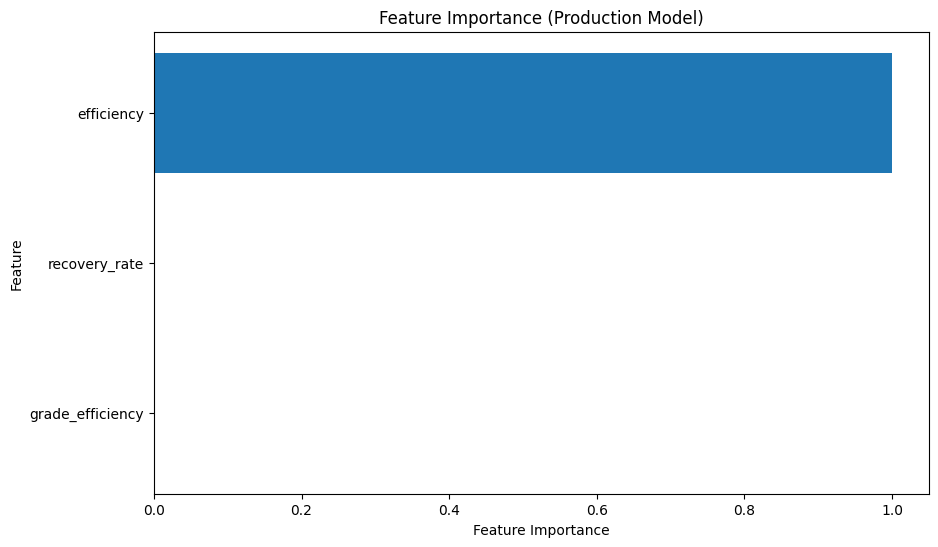

In [ ]:
def main():
    # Load data (assuming globals are available)
    optimizer = MiningOptimizationSystem()

    try:
        # Prepare features
        production_features = optimizer.prepare_production_features(
            minerals, commodities, processing
        )

        # Train models and get evaluation scores
        production_score = optimizer.train_production_model(production_features)
        maintenance_score = optimizer.predict_maintenance_needs(processing, waste)

        # Get the trained model for further analysis
        production_model = optimizer.production_predictor

        print("Models trained successfully")
        return {
            'production_model_score': production_score,
            'maintenance_model_accuracy': maintenance_score,
            'production_model': production_model  # Return the trained model
        }

    except Exception as e:
        print(f"Error during optimization: {str(e)}")
        return None

if __name__ == "__main__":
    results = main()
    if results:
        # Plot feature importance if model is returned
        plot_feature_importance(results['production_model'], ['efficiency', 'grade_efficiency', 'recovery_rate'])


In [ ]:
def plot_feature_importance(model, features):
    importances = model.feature_importances_
    if importances is None or len(importances) == 0:
        print("No feature importances found. Check if the model is trained properly.")
        return

    indices = np.argsort(importances)[::-1]

    plt.figure(figsize=(10, 6))
    plt.title("Feature Importances")
    plt.barh(range(len(features)), importances[indices], align="center")
    plt.yticks(range(len(features)), [features[i] for i in indices])
    plt.xlabel("Relative Importance")
    plt.show()

    # Print importances for debugging
    print("Feature Importances:", importances)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def create_visualizations(production_features, model_score):
    # Set style
    plt.style.use('seaborn')

    # Create figure with subplots
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))

    # 1. Production vs Predicted
    axes[0,0].scatter(production_features['value_tonnes_com'],
                     production_features['predicted_value'])
    axes[0,0].set_title('Actual vs Predicted Production')
    axes[0,0].set_xlabel('Actual Production')
    axes[0,0].set_ylabel('Predicted Production')

    # 2. Efficiency Distribution
    sns.histplot(production_features['efficiency'], ax=axes[0,1])
    axes[0,1].set_title('Efficiency Distribution')

    # 3. Recovery Rate vs Production
    axes[1,0].scatter(production_features['recovery_rate'],
                     production_features['value_tonnes_com'])
    axes[1,0].set_title('Recovery Rate vs Production')
    axes[1,0].set_xlabel('Recovery Rate')
    axes[1,0].set_ylabel('Production')

    # 4. Model Performance Text
    axes[1,1].text(0.5, 0.5, f'Model Score: {model_score:.2f}',
                   ha='center', va='center', fontsize=15)
    axes[1,1].axis('off')

    plt.tight_layout()
    return fig

# Usage in main function:
def main():
    # Your existing code...
    fig = create_visualizations(production_features, results['production_model_score'])
    plt.show()

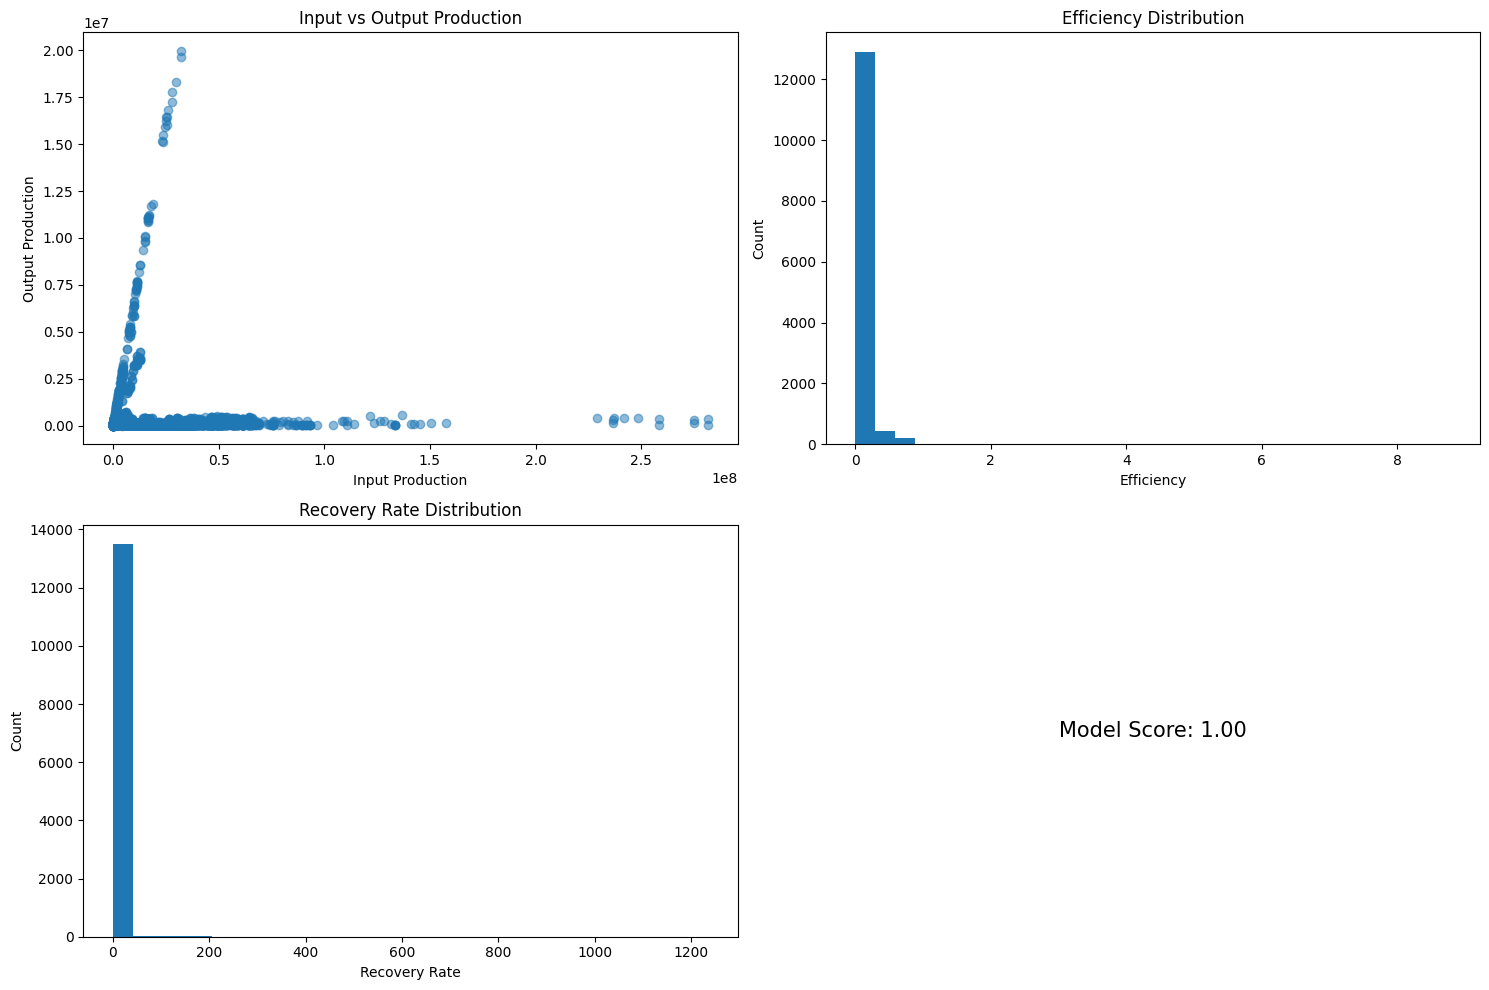

In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

class MiningOptimizationSystem:
    def __init__(self):
        self.scaler = StandardScaler()
        self.production_predictor = RandomForestRegressor(n_estimators=100)

    def prepare_features(self, minerals_df, commodities_df):
        df = pd.merge(
            minerals_df,
            commodities_df[['facility_id', 'year', 'material', 'value_tonnes', 'recovery_rate']],
            on=['facility_id', 'year', 'material'],
            suffixes=('_min', '_com')
        )

        df['efficiency'] = np.where(
            df['value_tonnes_min'] > 0,
            df['value_tonnes_com'] / df['value_tonnes_min'],
            0
        )

        return df

    def train_model(self, features_df):
        features = ['efficiency', 'value_tonnes_min']
        X = features_df[features].fillna(0)
        y = features_df['value_tonnes_com'].fillna(0)

        X = self.scaler.fit_transform(X)
        self.production_predictor.fit(X, y)
        return self.production_predictor.score(X, y)

def visualize_results(features, score):
    plt.figure(figsize=(15, 10))

    # Production Analysis
    plt.subplot(221)
    plt.scatter(features['value_tonnes_min'], features['value_tonnes_com'], alpha=0.5)
    plt.title('Input vs Output Production')
    plt.xlabel('Input Production')
    plt.ylabel('Output Production')

    # Efficiency Distribution
    plt.subplot(222)
    plt.hist(features['efficiency'].fillna(0), bins=30)
    plt.title('Efficiency Distribution')
    plt.xlabel('Efficiency')
    plt.ylabel('Count')

    # Recovery Rate Analysis
    plt.subplot(223)
    recovery_data = features['recovery_rate'].fillna(0)
    plt.hist(recovery_data, bins=30)
    plt.title('Recovery Rate Distribution')
    plt.xlabel('Recovery Rate')
    plt.ylabel('Count')

    # Model Performance
    plt.subplot(224)
    plt.text(0.5, 0.5, f'Model Score: {score:.2f}',
             horizontalalignment='center',
             verticalalignment='center',
             transform=plt.gca().transAxes,
             fontsize=15)
    plt.axis('off')

    plt.tight_layout()
    plt.show()

def main():
    optimizer = MiningOptimizationSystem()
    production_features = optimizer.prepare_features(minerals, commodities)
    model_score = optimizer.train_model(production_features)
    visualize_results(production_features, model_score)
    return {"model_score": model_score}

if __name__ == "__main__":
    results = main()

# Improving resource management

In [ ]:
from google.colab import drive
import pandas as pd
import os

# Mount Google Drive
drive.mount('/content/drive')

# Specify the path to your folder in Google Drive
folder_path = '/content/drive/MyDrive/Colab Notebooks/KFUPM/Challenge2'  # Update this path

# Get a list of all CSV files in the folder
csv_files = [f for f in os.listdir(folder_path) if f.endswith('.csv')]

# Create a dictionary to store dataframes
dataframes = {}

# Loop through each CSV file
for csv_file in csv_files:
  file_path = os.path.join(folder_path, csv_file)
  try:
      # Extract file name without extension
      file_name = os.path.splitext(csv_file)[0]

      # Read CSV into a pandas DataFrame
      globals()[file_name] = pd.read_csv(file_path)
      print(f"Successfully loaded '{csv_file}' as '{file_name}'")
  except FileNotFoundError:
    print(f"File '{csv_file}' not found.")
  except pd.errors.EmptyDataError:
    print(f"File '{csv_file}' is empty.")
  except pd.errors.ParserError:
    print(f"Error parsing '{csv_file}'. Check its format.")

print("owership:", ownership.columns)
print("minerals:", minerals.columns)
print("commodities:", commodities.columns)
print("source_ids:", source_ids.columns)
print("material_ids:", material_ids.columns)
print("reserves:", reserves.columns)
print("processing:", processing.columns)
print("capacity:", capacity.columns)
print("coal:", coal.columns)
print("transport:", transport.columns)
print("waste:", waste.columns)


Mounted at /content/drive
Successfully loaded 'processing.csv' as 'processing'
Successfully loaded 'minerals.csv' as 'minerals'
Successfully loaded 'coal.csv' as 'coal'
Successfully loaded 'capacity.csv' as 'capacity'
Successfully loaded 'reserves.csv' as 'reserves'
Successfully loaded 'source_ids.csv' as 'source_ids'
Successfully loaded 'commodities.csv' as 'commodities'
Successfully loaded 'ownership.csv' as 'ownership'
Successfully loaded 'material_ids.csv' as 'material_ids'
Successfully loaded 'waste.csv' as 'waste'
Successfully loaded 'transport.csv' as 'transport'
Successfully loaded 'prepared_data.csv' as 'prepared_data'
Successfully loaded 'processed_efficiency_results.csv' as 'processed_efficiency_results'
owership: Index(['id', 'facility_id', 'year', 'owners', 'operators', 'source_id',
       'comment'],
      dtype='object')
minerals: Index(['id', 'facility_id', 'year', 'type', 'material', 'value_tonnes',
       'overall_grade_ppm', 'amount_sold_tonnes', 'mine_processing',
 

In [ ]:
# Function to analyze and summarize dataframes
def analyze_dataframes(dataframes):
    for name, df in dataframes.items():
        print(f"\nAnalyzing '{name}' Dataset:")
        print("-" * 40)
        print("Basic Info:")
        print(df.info())
        print("\nMissing Values:")
        print(df.isnull().sum())
        print("\nSample Data:")
        print(df.head())
        print("\n" + "=" * 60)

# Store all dataframes in a dictionary for easier access
dataframes = {
    'ownership': ownership,
    'minerals': minerals,
    'commodities': commodities,
    'source_ids': source_ids,
    'material_ids': material_ids,
    'reserves': reserves,
    'processing': processing,
    'capacity': capacity,
    'coal': coal,
    'transport': transport,
    'waste': waste
}

# Analyze all dataframes
analyze_dataframes(dataframes)



Analyzing 'ownership' Dataset:
----------------------------------------
Basic Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 699 entries, 0 to 698
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   id           699 non-null    int64 
 1   facility_id  699 non-null    object
 2   year         699 non-null    int64 
 3   owners       698 non-null    object
 4   operators    143 non-null    object
 5   source_id    699 non-null    object
 6   comment      8 non-null      object
dtypes: int64(2), object(5)
memory usage: 38.4+ KB
None

Missing Values:
id               0
facility_id      0
year             0
owners           1
operators      556
source_id        0
comment        691
dtype: int64

Sample Data:
   id  facility_id  year                             owners operators  \
0   1  COM00001.00  2018         Hudbay Minerals Inc (100%)       NaN   
1   2  COM00005.00  2019                  Rusal Plc. (100%)    

In [ ]:
# Function to clean individual datasets
def clean_dataset(df, name):
    print(f"Cleaning {name}...")

    # Standardize column names
    df.columns = df.columns.str.lower().str.replace(' ', '_')

    # Handle missing values
    for col in df.columns:
        if df[col].dtype in ['float64', 'int64']:
            # Fill numeric columns with median
            df[col].fillna(df[col].median(), inplace=True)
        else:
            # Fill categorical columns with 'Unknown'
            df[col].fillna('Unknown', inplace=True)

    # Drop duplicates
    df.drop_duplicates(inplace=True)

    # Print summary after cleaning
    print(f"After cleaning {name}:")
    print(df.info())
    return df

# Apply cleaning to the relevant datasets
processing = clean_dataset(dataframes['processing'], 'processing')
reserves = clean_dataset(dataframes['reserves'], 'reserves')
waste = clean_dataset(dataframes['waste'], 'waste')
capacity = clean_dataset(dataframes['capacity'], 'capacity')


Cleaning processing...
After cleaning processing:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3979 entries, 0 to 3978
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    3979 non-null   int64  
 1   facility_id           3979 non-null   object 
 2   facility_type         3979 non-null   object 
 3   year                  3979 non-null   int64  
 4   input                 3979 non-null   object 
 5   input_value_tonnes    3979 non-null   float64
 6   output                3979 non-null   object 
 7   output_value_tonnes   3979 non-null   float64
 8   grade_ppm             3979 non-null   float64
 9   recovery_rate         3979 non-null   float64
 10  amount_sold_tonnes    3979 non-null   float64
 11  metal_payable_tonnes  0 non-null      float64
 12  incl_purchased        3979 non-null   object 
 13  reporting_period      3979 non-null   object 
 14  source_id             

<ipython-input-4-9316067a82a4>:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
<ipython-input-4-9316067a82a4>:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 

In [ ]:
# Merge processing and reserves datasets
merged_data = pd.merge(
    processing, reserves,
    on=['facility_id', 'year'],
    how='inner',
    suffixes=('_processing', '_reserves')
)

# Merge with waste data
merged_data = pd.merge(
    merged_data, waste,
    on=['facility_id', 'year'],
    how='left',
    suffixes=('', '_waste')
)

# Merge with capacity data
merged_data = pd.merge(
    merged_data, capacity,
    on=['facility_id', 'year'],
    how='left',
    suffixes=('', '_capacity')
)

print("Merged Dataset Info:")
print(merged_data.info())


Merged Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80 entries, 0 to 79
Data columns (total 41 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id_processing           80 non-null     int64  
 1   facility_id             80 non-null     object 
 2   facility_type           80 non-null     object 
 3   year                    80 non-null     int64  
 4   input                   80 non-null     object 
 5   input_value_tonnes      80 non-null     float64
 6   output                  80 non-null     object 
 7   output_value_tonnes     80 non-null     float64
 8   grade_ppm_processing    80 non-null     float64
 9   recovery_rate           80 non-null     float64
 10  amount_sold_tonnes      80 non-null     float64
 11  metal_payable_tonnes    0 non-null      float64
 12  incl_purchased          80 non-null     object 
 13  reporting_period        80 non-null     object 
 14  source_id_processing   

In [ ]:
# Add calculated columns
merged_data['efficiency'] = (
    merged_data['output_value_tonnes'] /
    merged_data['input_value_tonnes']
).fillna(0)  # Avoid division by zero

merged_data['waste_ratio'] = (
    merged_data['value_tonnes'] /
    merged_data['output_value_tonnes']
).fillna(0)

merged_data['capacity_utilization'] = (
    merged_data['input_value_tonnes'] /
    merged_data['value_tpa']
).fillna(0)

# Create time-series features (optional)
merged_data['yearly_growth'] = merged_data.groupby('facility_id')['output_value_tonnes'].pct_change()

print("Feature Engineering Complete:")
print(merged_data[['efficiency', 'waste_ratio', 'capacity_utilization', 'yearly_growth']].describe())


Feature Engineering Complete:
         efficiency   waste_ratio  capacity_utilization  yearly_growth
count  8.000000e+01  8.000000e+01             80.000000      65.000000
mean   1.573644e+00  5.042812e+05              0.121300      20.633503
std    3.196761e+00  3.153414e+06              0.312584     137.021300
min    1.688835e-07  0.000000e+00              0.000000      -0.999992
25%    7.833403e-02  0.000000e+00              0.000000       0.000000
50%    3.609156e-01  0.000000e+00              0.000000       0.000000
75%    1.318019e+00  9.685531e+01              0.010961       0.000000
max    1.726947e+01  2.007367e+07              2.046000    1087.535755


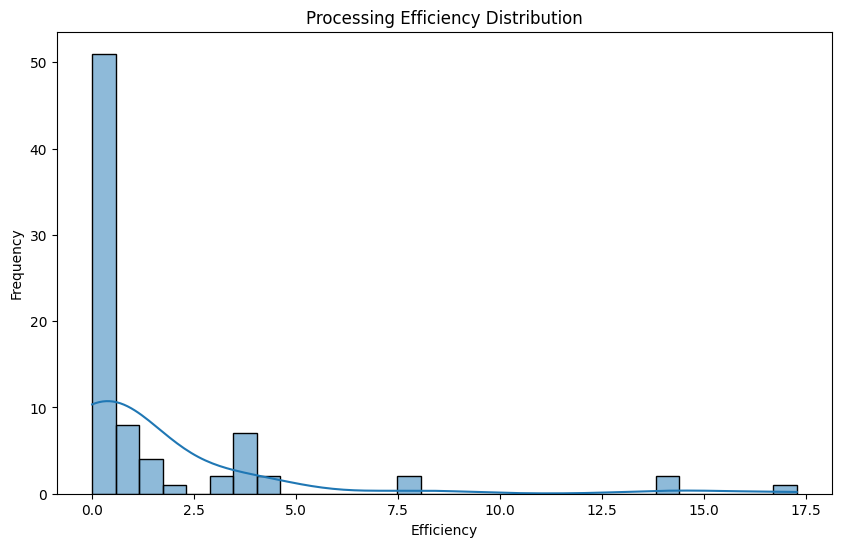

Facilities with Low Efficiency:
    facility_id    efficiency  year
4   COM00343.00  1.688835e-07  2018
49  COM00693.00  4.002933e-06  2018
48  COM00693.00  4.002933e-06  2018
51  COM00693.00  8.611926e-04  2018
50  COM00693.00  8.611926e-04  2018
62  COM01189.00  2.931034e-02  2019
2   COM00321.00  4.203324e-02  2019
75  COM01435.00  5.262300e-02  2019
73  COM01435.00  5.262300e-02  2019
72  COM01435.00  5.262300e-02  2019


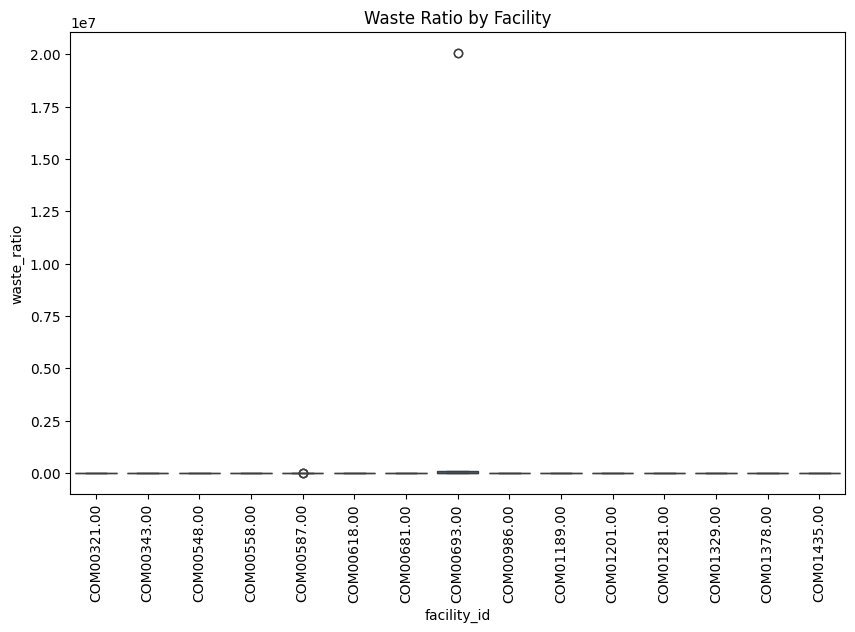

Number of underutilized facilities: 73


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Plot efficiency distribution
plt.figure(figsize=(10, 6))
sns.histplot(merged_data['efficiency'], bins=30, kde=True)
plt.title('Processing Efficiency Distribution')
plt.xlabel('Efficiency')
plt.ylabel('Frequency')
plt.show()

# Facilities with the lowest efficiency
low_efficiency = merged_data[merged_data['efficiency'] < 0.5]
print("Facilities with Low Efficiency:")
print(low_efficiency[['facility_id', 'efficiency', 'year']].sort_values(by='efficiency').head(10))

# Plot waste ratio by facility
plt.figure(figsize=(10, 6))
sns.boxplot(data=merged_data, x='facility_id', y='waste_ratio')
plt.title('Waste Ratio by Facility')
plt.xticks(rotation=90)
plt.show()

# Analyze capacity utilization
underutilized = merged_data[merged_data['capacity_utilization'] < 0.5]
print(f"Number of underutilized facilities: {len(underutilized)}")


In [ ]:
# Set a threshold for high waste ratio (e.g., > 1)
high_waste_facilities = merged_data[merged_data['waste_ratio'] > 1]

# Analyze these facilities
print("Facilities with High Waste Ratios:")
print(high_waste_facilities[['facility_id', 'waste_ratio', 'value_tonnes', 'output_value_tonnes', 'year']].sort_values(by='waste_ratio'))


Facilities with High Waste Ratios:
    facility_id   waste_ratio  value_tonnes  output_value_tonnes  year
35  COM00587.00  6.868947e+00     1787300.0         2.602000e+05  2019
33  COM00587.00  6.868947e+00     1787300.0         2.602000e+05  2019
31  COM00587.00  6.868947e+00     1787300.0         2.602000e+05  2019
19  COM00587.00  1.670374e+01     1787300.0         1.070000e+05  2019
21  COM00587.00  1.670374e+01     1787300.0         1.070000e+05  2019
23  COM00587.00  1.670374e+01     1787300.0         1.070000e+05  2019
55  COM00693.00  2.459900e+01    24660500.0         1.002500e+06  2018
54  COM00693.00  2.459900e+01    24660500.0         1.002500e+06  2018
40  COM00618.00  4.898493e+01    55255000.0         1.128000e+06  2017
41  COM00618.00  4.898493e+01    55255000.0         1.128000e+06  2017
42  COM00618.00  4.898493e+01    55255000.0         1.128000e+06  2017
27  COM00587.00  5.728526e+01     1787300.0         3.120000e+04  2019
25  COM00587.00  5.728526e+01     1787300.

In [ ]:
# Set a threshold for low capacity utilization (e.g., < 0.5)
low_utilization = merged_data[merged_data['capacity_utilization'] < 0.5]

# Analyze these facilities
print("Underutilized Facilities:")
print(low_utilization[['facility_id', 'capacity_utilization', 'value_tpa', 'input_value_tonnes', 'year']].sort_values(by='capacity_utilization'))


Underutilized Facilities:
    facility_id  capacity_utilization  value_tpa  input_value_tonnes  year
0   COM00321.00                0.0000        NaN            306900.0  2019
33  COM00587.00                0.0000        NaN            455000.0  2019
34  COM00587.00                0.0000        NaN            455000.0  2019
35  COM00587.00                0.0000        NaN            455000.0  2019
37  COM00618.00                0.0000        NaN           1211740.0  2017
..          ...                   ...        ...                 ...   ...
68  COM01435.00                0.3069  1000000.0            306900.0  2019
70  COM01435.00                0.3069  1000000.0            306900.0  2019
72  COM01435.00                0.3069  1000000.0            306900.0  2019
74  COM01435.00                0.3069  1000000.0            306900.0  2019
78  COM01435.00                0.3069  1000000.0            306900.0  2019

[73 rows x 5 columns]


Correlation Matrix:
                     efficiency  input_value_tonnes  output_value_tonnes  \
efficiency             1.000000           -0.083780             0.998270   
input_value_tonnes    -0.083780            1.000000            -0.075498   
output_value_tonnes    0.998270           -0.075498             1.000000   
waste_ratio           -0.079714           -0.029065            -0.083467   

                     waste_ratio  
efficiency             -0.079714  
input_value_tonnes     -0.029065  
output_value_tonnes    -0.083467  
waste_ratio             1.000000  


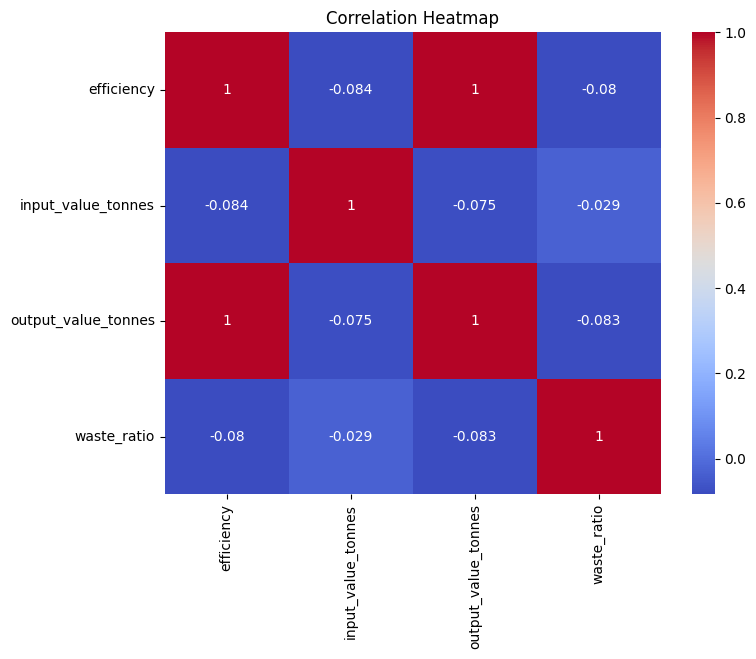

In [ ]:
# Analyze correlations
correlation_matrix = merged_data[['efficiency', 'input_value_tonnes', 'output_value_tonnes', 'waste_ratio']].corr()
print("Correlation Matrix:")
print(correlation_matrix)

# Heatmap visualization
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


In [ ]:
print(reserves.columns)


Index(['id', 'facility_id', 'year', 'material', 'commodity',
       'mineral_value_tonnes', 'commodity_value_tonnes', 'grade_ppm',
       'source_id', 'comment'],
      dtype='object')


In [ ]:
# Add efficiency column to reserves
reserves['efficiency'] = reserves['commodity_value_tonnes'] / (reserves['mineral_value_tonnes'] + 1e-6)

# Handle cases where efficiency could not be computed
reserves['efficiency'] = reserves['efficiency'].fillna(0)  # Replace NaN with 0


# Drop rows with missing target (efficiency)
df = reserves.dropna(subset=['efficiency'])

# Display the first few rows
print(df.head())


   id  facility_id  year material commodity  mineral_value_tonnes  \
0   1  COM00001.00  2019   O.bulk     Me.Ag             3552000.0   
1   2  COM00001.00  2019   O.bulk     Me.Au             3552000.0   
2   3  COM00001.00  2019   O.bulk     Me.Cu             3552000.0   
3   4  COM00001.00  2019   O.bulk     Me.Zn             3552000.0   
4   5  COM00002.00  2019     O.Fe     Me.Fe            56300000.0   

   commodity_value_tonnes  grade_ppm source_id  comment  efficiency  
0              153.065992       6.02  det_2832  Unknown    0.000043  
1              153.065992       6.02  det_2832  Unknown    0.000043  
2              153.065992       6.02  det_2832  Unknown    0.000043  
3              153.065992       6.02  det_2832  Unknown    0.000043  
4              153.065992       6.02  det_1307  Unknown    0.000003  


In [ ]:
# Threshold for low efficiency
low_efficiency_threshold = 0.1  # Example threshold, adjust as needed

# Filter for low-efficiency facilities
low_efficiency_facilities = df[df['efficiency'] < low_efficiency_threshold]

print("Facilities with Low Efficiency:")
print(low_efficiency_facilities[['facility_id', 'efficiency', 'year']])


Facilities with Low Efficiency:
      facility_id  efficiency  year
0     COM00001.00    0.000043  2019
1     COM00001.00    0.000043  2019
2     COM00001.00    0.000043  2019
3     COM00001.00    0.000043  2019
4     COM00002.00    0.000003  2019
...           ...         ...   ...
1034  COM01432.00    0.000076  2019
1035  COM01432.00    0.034301  2019
1036  COM01432.00    0.074242  2019
1037  COM01435.00    0.000015  2019
1038  COM01435.00    0.000015  2019

[1037 rows x 3 columns]


In [ ]:
# Summary statistics for efficiency
efficiency_stats = df['efficiency'].describe()
print(efficiency_stats)


count    1.039000e+03
mean     1.037870e+00
std      3.158903e+01
min      4.399696e-11
25%      7.198302e-07
50%      3.661866e-06
75%      2.409158e-05
max      1.016491e+03
Name: efficiency, dtype: float64


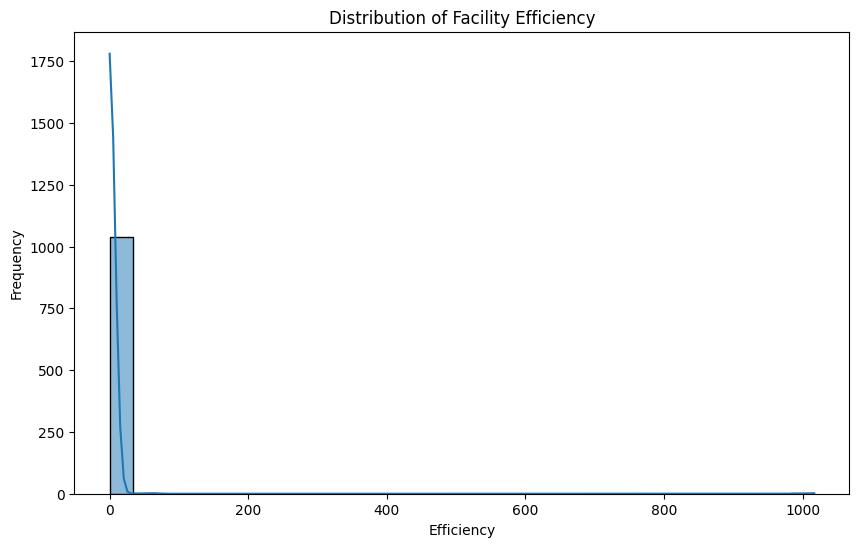

Facilities with the lowest average efficiency:
facility_id
COM00495.00    4.399696e-11
COM00221.00    6.187732e-09
COM01174.00    1.691337e-08
COM00397.00    2.030322e-08
COM01194.00    2.501133e-08
COM01229.00    3.061320e-08
COM00233.00    3.643394e-08
COM01156.00    3.646078e-08
COM00178.00    3.731494e-08
COM01237.00    3.885910e-08
Name: efficiency, dtype: float64
Correlation matrix:
                               id      year  mineral_value_tonnes  \
id                      1.000000  0.068997             -0.050280   
year                    0.068997  1.000000              0.072419   
mineral_value_tonnes   -0.050280  0.072419              1.000000   
commodity_value_tonnes  0.009053  0.026134             -0.009252   
grade_ppm               0.035870  0.058689             -0.043780   
efficiency              0.009318  0.026074             -0.009940   

                        commodity_value_tonnes  grade_ppm  efficiency  
id                                    0.009053   0.035870 

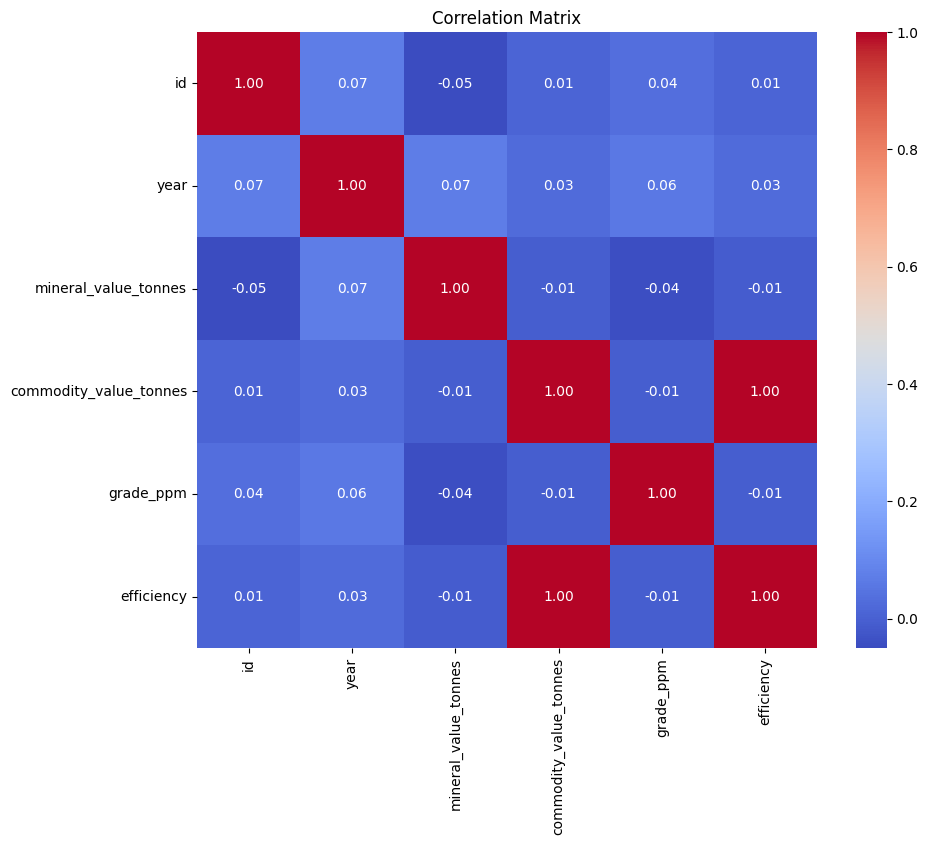

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot histogram of efficiency
plt.figure(figsize=(10, 6))
sns.histplot(df['efficiency'], bins=30, kde=True)
plt.title("Distribution of Facility Efficiency")
plt.xlabel("Efficiency")
plt.ylabel("Frequency")
plt.show()

# Group by facility and calculate average efficiency
low_efficiency_summary = low_efficiency_facilities.groupby('facility_id')['efficiency'].mean().sort_values()

print("Facilities with the lowest average efficiency:")
print(low_efficiency_summary.head(10))

# Select only numeric columns
numeric_df = df.select_dtypes(include=['float64', 'int64'])

# Calculate correlation matrix
correlation_matrix = numeric_df.corr()

# Display correlation matrix
print("Correlation matrix:\n", correlation_matrix)

# Optional: Visualize the correlation matrix
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Correlation Matrix")
plt.show()



Empty DataFrame
Columns: [facility_id, year, commodity, material]
Index: []
Efficiency Trends by Year:
 year
2002    0.000004
2003    0.000005
2005    0.000594
2006    0.000004
2007    0.000017
2008    0.000004
2009    0.000020
2010    0.000029
2011    0.000021
2012    0.000003
2013    0.001273
2014    0.000195
2015    0.000488
2016    0.000078
2017    0.000109
2018    0.001781
2019    0.001789
2020    8.615977
Name: efficiency, dtype: float64


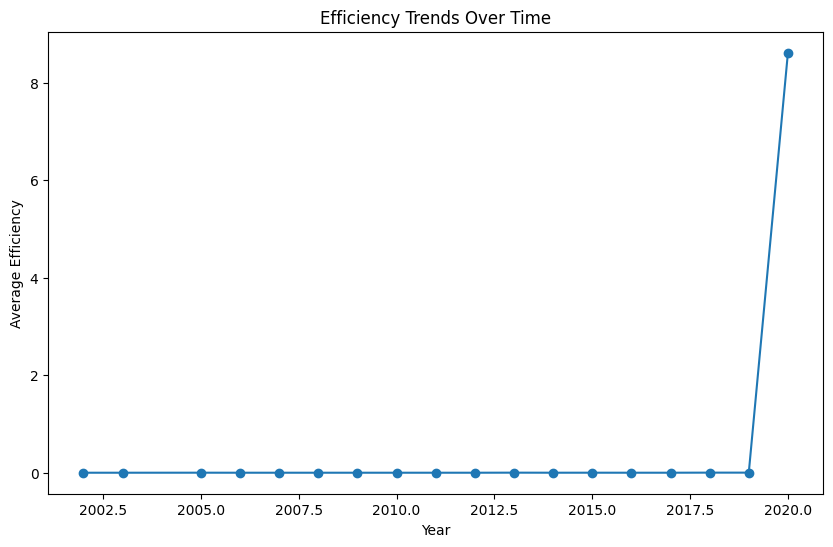

In [ ]:
# Check for patterns in facilities with zero efficiency
zero_efficiency_facilities = df[df['efficiency'] == 0]
print(zero_efficiency_facilities[['facility_id', 'year', 'commodity', 'material']].drop_duplicates())

# Analyze trends in efficiency by year
efficiency_trends = df.groupby('year')['efficiency'].mean()
print("Efficiency Trends by Year:\n", efficiency_trends)

# Plot the trend
efficiency_trends.plot(kind='line', marker='o', figsize=(10, 6), title='Efficiency Trends Over Time')
plt.ylabel('Average Efficiency')
plt.xlabel('Year')
plt.show()


Empty DataFrame
Columns: [facility_id, year, commodity, material]
Index: []
         efficiency
count  1.250000e+02
mean   8.615977e+00
std    9.103464e+01
min    6.187732e-09
25%    7.529588e-07
50%    2.074065e-06
75%    6.122640e-06
max    1.016491e+03
Average Efficiency by Commodity:
 commodity
Me.Ag       9.589761e+00
Me.Au       2.518683e-01
Nm.S        2.118855e-02
Me.Zn       7.624245e-03
Me.Ni       6.811737e-03
Me.Sn       5.853816e-03
Me.Cu       4.114751e-03
Me.Pb       4.050786e-03
Me.WO3      3.636364e-03
O.TiO2      3.401558e-03
Me.Co       5.122402e-04
Me.U        1.367035e-04
Me.Nb       8.737382e-05
Nm.SiO2     5.804238e-05
Me.Al2O3    5.190367e-05
Me.Cr2O3    4.289361e-05
Me.Te       3.644428e-05
Nm.dia      2.019621e-05
Me.Li2O     1.866658e-05
Me.Fe       1.420458e-05
Me.Mn       1.342847e-05
Me.Mo       1.194427e-05
Me.KCl      1.186558e-05
Unknown     9.210259e-06
Me.pgm      7.612194e-06
Me.Pd       1.677741e-06
Nm.PO       1.142155e-06
O.FeTiO3    1.096905e-06


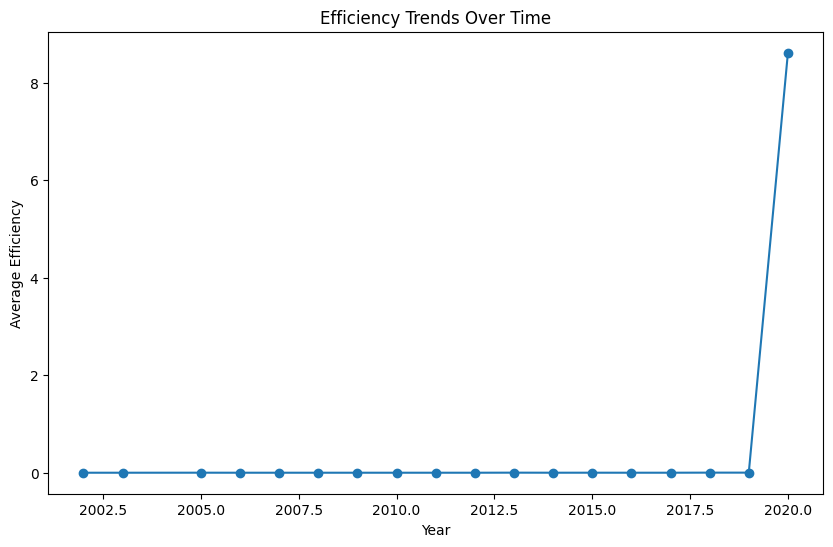

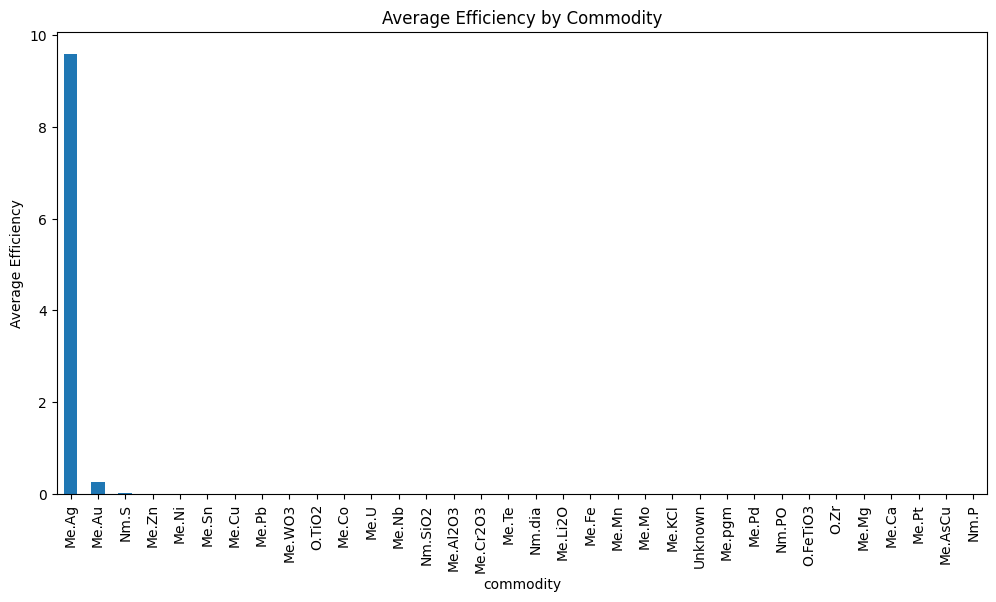

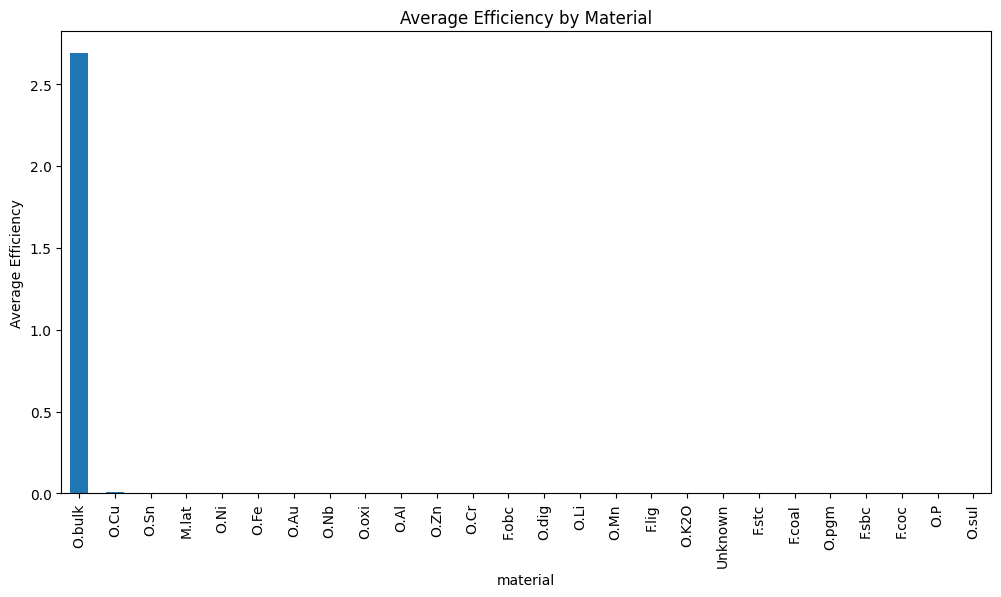

In [ ]:
zero_efficiency_facilities = df[df['efficiency'] == 0]
print(zero_efficiency_facilities[['facility_id', 'year', 'commodity', 'material']].drop_duplicates())
efficiency_2020 = df[df['year'] == 2020]
print(efficiency_2020[['facility_id', 'commodity', 'material', 'efficiency']].describe())



avg_efficiency_by_commodity = df.groupby('commodity')['efficiency'].mean().sort_values(ascending=False)
print("Average Efficiency by Commodity:\n", avg_efficiency_by_commodity)

avg_efficiency_by_material = df.groupby('material')['efficiency'].mean().sort_values(ascending=False)
print("Average Efficiency by Material:\n", avg_efficiency_by_material)


import matplotlib.pyplot as plt

efficiency_trends.plot(kind='line', marker='o', figsize=(10, 6), title='Efficiency Trends Over Time')
plt.ylabel('Average Efficiency')
plt.xlabel('Year')
plt.show()


avg_efficiency_by_commodity.plot(kind='bar', figsize=(12, 6), title='Average Efficiency by Commodity')
plt.ylabel('Average Efficiency')
plt.show()

avg_efficiency_by_material.plot(kind='bar', figsize=(12, 6), title='Average Efficiency by Material')
plt.ylabel('Average Efficiency')
plt.show()


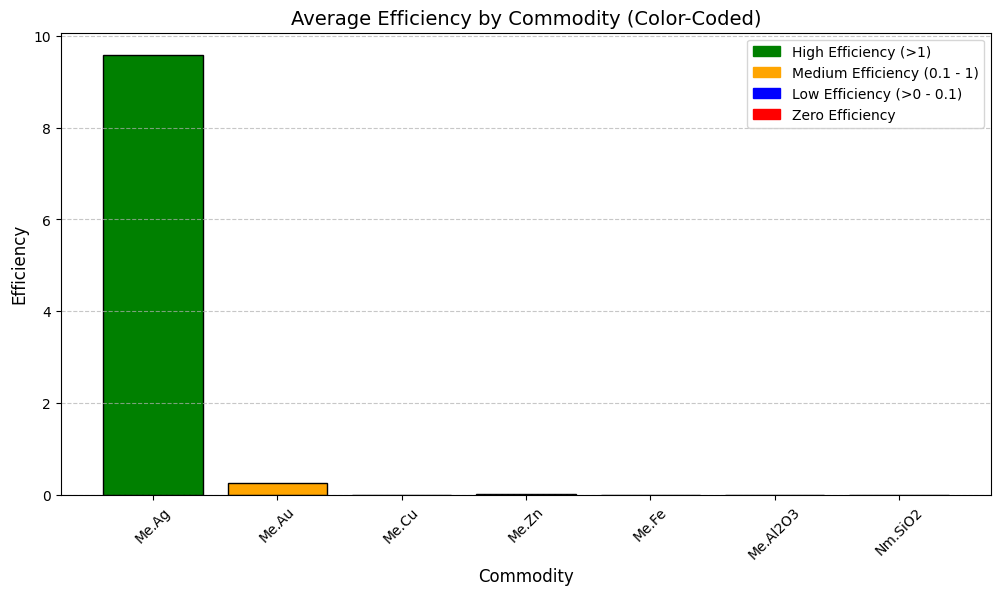

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Example Data (Replace with your DataFrame)
data = {
    'commodity': ['Me.Ag', 'Me.Au', 'Me.Cu', 'Me.Zn', 'Me.Fe', 'Me.Al2O3', 'Nm.SiO2'],
    'efficiency': [9.589582, 0.251782, 0.003702, 0.006537, 0.0, 0.0, 0.0]
}
df = pd.DataFrame(data)

# Define color thresholds
def assign_color(value):
    if value > 1:       # High efficiency
        return 'green'
    elif value > 0.1:   # Medium efficiency
        return 'orange'
    elif value > 0:     # Low efficiency
        return 'blue'
    else:               # Zero efficiency
        return 'red'

# Assign colors based on efficiency
colors = df['efficiency'].apply(assign_color)

# Plot the bar chart
plt.figure(figsize=(12, 6))
plt.bar(df['commodity'], df['efficiency'], color=colors, edgecolor='black')

# Add labels and title
plt.title('Average Efficiency by Commodity (Color-Coded)', fontsize=14)
plt.xlabel('Commodity', fontsize=12)
plt.ylabel('Efficiency', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add a legend
import matplotlib.patches as mpatches
legend_patches = [
    mpatches.Patch(color='green', label='High Efficiency (>1)'),
    mpatches.Patch(color='orange', label='Medium Efficiency (0.1 - 1)'),
    mpatches.Patch(color='blue', label='Low Efficiency (>0 - 0.1)'),
    mpatches.Patch(color='red', label='Zero Efficiency')
]
plt.legend(handles=legend_patches, loc='upper right')

# Show the plot
plt.show()


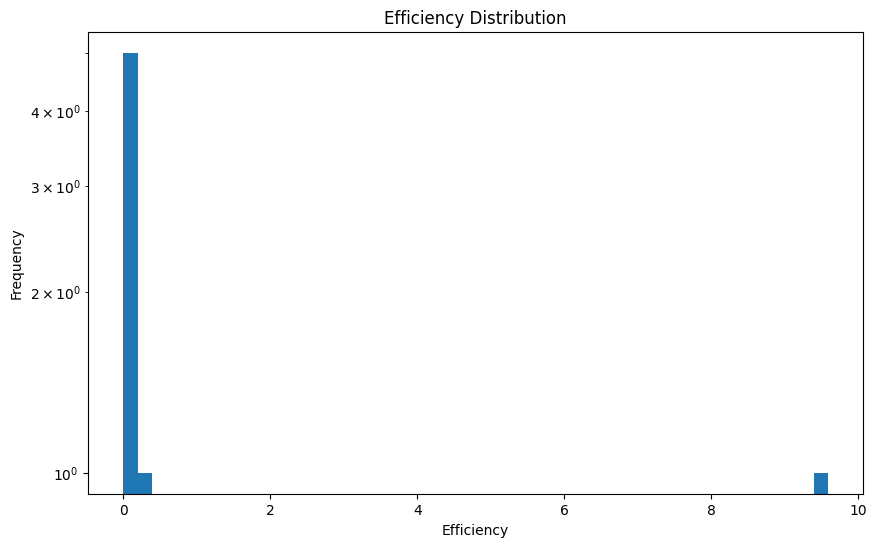

           count      mean  std
commodity                      
Me.Ag          1  9.589582  NaN
Me.Au          1  0.251782  NaN
Me.Zn          1  0.006537  NaN
Me.Cu          1  0.003702  NaN
Me.Al2O3       1  0.000000  NaN
Me.Fe          1  0.000000  NaN
Nm.SiO2        1  0.000000  NaN


In [ ]:
import matplotlib.pyplot as plt

# Histogram of efficiency
df['efficiency'].plot(kind='hist', bins=50, logy=True, title='Efficiency Distribution', figsize=(10, 6))
plt.xlabel('Efficiency')
plt.ylabel('Frequency')
plt.show()


# Group by commodity or material
commodity_analysis = df.groupby('commodity')['efficiency'].agg(['count', 'mean', 'std']).sort_values('mean', ascending=False)
print(commodity_analysis)



In [ ]:
print(df.columns)


Index(['commodity', 'efficiency'], dtype='object')


Mean Absolute Error: 0.00033495755564854447
R-squared: 0.9219336825612825


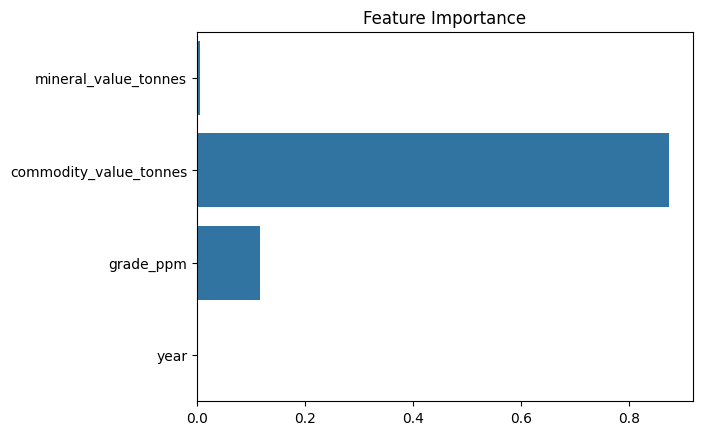

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

# Selecting relevant columns for modeling
features = ['mineral_value_tonnes', 'commodity_value_tonnes', 'grade_ppm', 'year']
target = 'efficiency'

# Dropping rows with missing target
df = reserves.dropna(subset=[target])

# Splitting data
X = df[features]
y = df[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scaling features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Training the model
model = RandomForestRegressor(random_state=42)
model.fit(X_train_scaled, y_train)

# Predictions
y_pred = model.predict(X_test_scaled)

# Model evaluation
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error: {mae}")
print(f"R-squared: {r2}")

# Feature importance
importance = model.feature_importances_
sns.barplot(x=importance, y=features)
plt.title("Feature Importance")
plt.show()


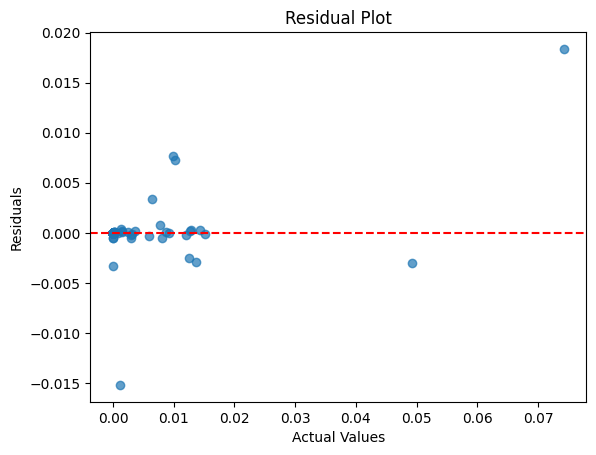

Cross-Validation R² Scores: [ 0.88594289  0.94824436 -0.00540199  0.91303648  0.89119113]
Mean R² Score: 0.7266025731390519


In [ ]:
residuals = y_test - y_pred
plt.scatter(y_test, residuals, alpha=0.7)
plt.axhline(0, color='red', linestyle='--')
plt.title("Residual Plot")
plt.xlabel("Actual Values")
plt.ylabel("Residuals")
plt.show()
from sklearn.model_selection import cross_val_score
cv_scores = cross_val_score(model, X, y, cv=5, scoring='r2')
print(f"Cross-Validation R² Scores: {cv_scores}")
print(f"Mean R² Score: {cv_scores.mean()}")


<ipython-input-25-948e4601aed4>:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


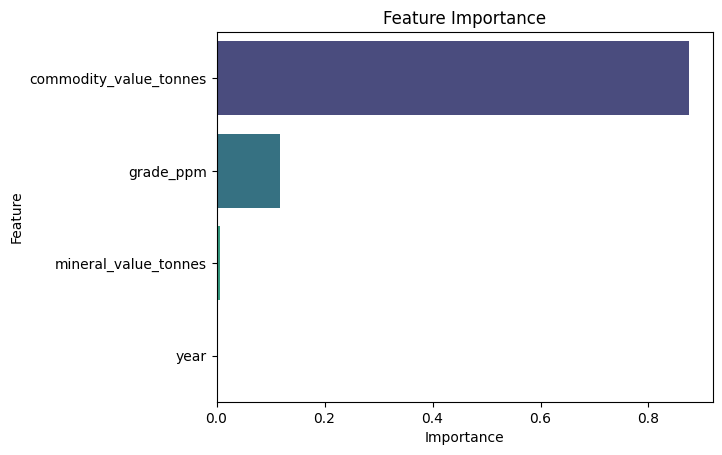

In [ ]:
# Feature importance
importance = model.feature_importances_

# Create a DataFrame for easier plotting
importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': importance
})

# Sort by importance for better visualization
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Plot with different colors
sns.barplot(
    x='Importance',
    y='Feature',
    data=importance_df,
    palette='viridis'  # Choose a color palette (e.g., viridis, coolwarm, plasma)
)
plt.title("Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()
